<a href="https://colab.research.google.com/github/Nicolascollao27/ICS40125-entregables/blob/main/Proyecto_2_ABC_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío de Clasificación — Predicción de Abandono de Clientes en ABC Multistate Bank


## Contexto y Objetivo

ABC Multistate Bank ha observado recientemente un número creciente de clientes que cierran sus cuentas. La pérdida de clientes no solo reduce los ingresos inmediatos, sino que también incrementa los costos de marketing necesarios para captar nuevos clientes. Para abordar este problema, el equipo de datos ha sido convocado para desarrollar un **modelo de clasificación** que prediga si un cliente tiene probabilidad de abandonar el banco (*churn*) en el corto plazo.

Su misión es actuar como **Experto en Datos** en ABC Bank y construir modelos predictivos que permitan al equipo de negocio identificar clientes en riesgo de abandono, de modo que el banco pueda tomar acciones preventivas a tiempo.





## Descripción del Dataset

El dataset contiene información de **10.000 clientes** del banco. La tarea consiste en predecir la variable `churn`, que indica si un cliente ha abandonado el banco (1) o no (0).

| Variable | Descripción |
|---|---|
| `customer_id` | Identificador único del cliente (no se usa en el modelado) |
| `credit_score` | Puntaje crediticio del cliente |
| `country` | País del cliente (France, Spain, Germany) |
| `gender` | Género (Male, Female) |
| `age` | Edad del cliente |
| `tenure` | Años de relación con el banco |
| `balance` | Saldo de la cuenta |
| `products_number` | Número de productos contratados |
| `credit_card` | Si el cliente tiene tarjeta de crédito (1/0) |
| `active_member` | Si el cliente es miembro activo (1/0) |
| `estimated_salary` | Salario anual estimado |
| `churn` | **Variable objetivo** (1 = abandonó, 0 = retenido) |



In [ ]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/projects/data/bank.csv'
df = pd.read_csv(path, sep="," )

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0




## Estructura del Proyecto

Deberá entregar un informe analítico completo que cubra tanto los aspectos técnicos como los de negocio. El notebook o informe debe incluir las siguientes secciones:


### 1. Introducción

- Presente el problema de negocio con sus propias palabras.
- Explique por qué predecir el *churn* es valioso para ABC Bank.
- Defina con claridad el objetivo del proyecto.



In [ ]:
from IPython.display import display, Markdown

display(Markdown("""
# 1. Introducción

## Problema de negocio

ABC Bank enfrenta el desafío de identificar oportunamente a los clientes con mayor probabilidad de abandonar la institución financiera, fenómeno conocido como **churn**. La pérdida de clientes puede afectar los ingresos futuros, elevar los costos de captación de nuevos usuarios y debilitar la relación comercial de largo plazo.

El banco dispone de información demográfica, financiera y de comportamiento de sus clientes, como puntaje de crédito, país, género, edad, antigüedad, saldo en cuenta, número de productos contratados, tenencia de tarjeta de crédito, condición de cliente activo y salario estimado. Esta información puede utilizarse para detectar patrones asociados a una mayor probabilidad de fuga.

## ¿Por qué predecir el churn es valioso para ABC Bank?

Predecir el churn permite anticiparse a la salida de clientes antes de que esta ocurra. Esto ayuda a ABC Bank a focalizar acciones de retención en los segmentos con mayor riesgo, tales como ofertas personalizadas, mejoras de servicio, campañas de fidelización, asesoría financiera o revisión de productos contratados.

Desde una perspectiva económica, retener clientes suele ser más eficiente que reemplazarlos, ya que captar nuevos clientes requiere inversión en marketing, procesos comerciales, evaluación de riesgo y servicio inicial. Por ello, un modelo predictivo puede apoyar una asignación más eficiente de los recursos comerciales y mejorar la rentabilidad de la cartera de clientes.

## Objetivo del proyecto

El objetivo de este proyecto es construir, entrenar y comparar distintos modelos de clasificación supervisada capaces de estimar la probabilidad de que un cliente abandone ABC Bank.

En particular, se buscará:

1. Explorar y preparar la base de datos de clientes.
2. Identificar las variables más relacionadas con el churn.
3. Entrenar distintos modelos predictivos, tales como regresión logística, árbol de decisión, Random Forest y Gradient Boosting.
4. Evaluar los modelos utilizando métricas como accuracy, precision, recall, F1-score y ROC-AUC.
5. Seleccionar el modelo más adecuado para apoyar decisiones de retención de clientes.
6. Proponer recomendaciones estratégicas para reducir la fuga de clientes según los resultados obtenidos.
"""))


# 1. Introducción

## Problema de negocio

ABC Bank enfrenta el desafío de identificar oportunamente a los clientes con mayor probabilidad de abandonar la institución financiera, fenómeno conocido como **churn**. La pérdida de clientes puede afectar los ingresos futuros, elevar los costos de captación de nuevos usuarios y debilitar la relación comercial de largo plazo.

El banco dispone de información demográfica, financiera y de comportamiento de sus clientes, como puntaje de crédito, país, género, edad, antigüedad, saldo en cuenta, número de productos contratados, tenencia de tarjeta de crédito, condición de cliente activo y salario estimado. Esta información puede utilizarse para detectar patrones asociados a una mayor probabilidad de fuga.

## ¿Por qué predecir el churn es valioso para ABC Bank?

Predecir el churn permite anticiparse a la salida de clientes antes de que esta ocurra. Esto ayuda a ABC Bank a focalizar acciones de retención en los segmentos con mayor riesgo, tales como ofertas personalizadas, mejoras de servicio, campañas de fidelización, asesoría financiera o revisión de productos contratados.

Desde una perspectiva económica, retener clientes suele ser más eficiente que reemplazarlos, ya que captar nuevos clientes requiere inversión en marketing, procesos comerciales, evaluación de riesgo y servicio inicial. Por ello, un modelo predictivo puede apoyar una asignación más eficiente de los recursos comerciales y mejorar la rentabilidad de la cartera de clientes.

## Objetivo del proyecto

El objetivo de este proyecto es construir, entrenar y comparar distintos modelos de clasificación supervisada capaces de estimar la probabilidad de que un cliente abandone ABC Bank.

En particular, se buscará:

1. Explorar y preparar la base de datos de clientes.
2. Identificar las variables más relacionadas con el churn.
3. Entrenar distintos modelos predictivos, tales como regresión logística, árbol de decisión, Random Forest y Gradient Boosting.
4. Evaluar los modelos utilizando métricas como accuracy, precision, recall, F1-score y ROC-AUC.
5. Seleccionar el modelo más adecuado para apoyar decisiones de retención de clientes.
6. Proponer recomendaciones estratégicas para reducir la fuga de clientes según los resultados obtenidos.




### 2. Análisis Exploratorio de Datos (EDA)

Realice un análisis exploratorio riguroso para comprender los datos y extraer conclusiones relevantes.

El EDA debe incluir obligatoriamente:

- **Descripción general del dataset:** estructura, tipos de datos, duplicados y valores faltantes.
- **Análisis univariado:** distribuciones de variables numéricas y proporciones de variables categóricas.
- **Análisis bivariado:** relaciones entre los predictores y la variable `churn`.
- **Detección de valores atípicos:** identificación de valores extremos mediante IQR o z-scores.
- **Análisis de valores faltantes:** descripción de cantidad y ubicación, con hipótesis sobre sus posibles causas.

A continuación, **decida y justifique**:

- ¿Cómo tratará los valores atípicos? (p.ej., winsorización, eliminación, transformación)
- ¿Cómo imputará los datos faltantes? (p.ej., media/mediana, moda, métodos predictivos)
- ¿Hay variables que deban eliminarse o transformarse?



RESUMEN GENERAL DEL DATASET
Número de filas: 10,000
Número de columnas: 12
Duplicados exactos: 0
Registros repetidos excluyendo customer_id: 0

Tipos de datos:


,tipo_de_dato
customer_id,int64
credit_score,int64
country,string[python]
gender,string[python]
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64



Calidad de las variables:


,tipo,no_nulos,nulos,porcentaje_nulos,valores_unicos
customer_id,int64,10000,0,0.000,10000
credit_score,int64,10000,0,0.000,460
country,string,10000,0,0.000,3
gender,string,10000,0,0.000,2
age,int64,10000,0,0.000,70
tenure,int64,10000,0,0.000,11
balance,float64,10000,0,0.000,6382
products_number,int64,10000,0,0.000,4
credit_card,int64,10000,0,0.000,2
active_member,int64,10000,0,0.000,2



Distribución de la variable objetivo:


,churn,cantidad_clientes,porcentaje,interpretacion
0,0,7963,79.630,Cliente que permanece en el banco
1,1,2037,20.370,Cliente que abandona el banco



Tasa total de churn: 20.37%
Diagnóstico: existe desbalance de clases moderado. En los modelos se recomienda utilizar estratificación y pesos de clase.


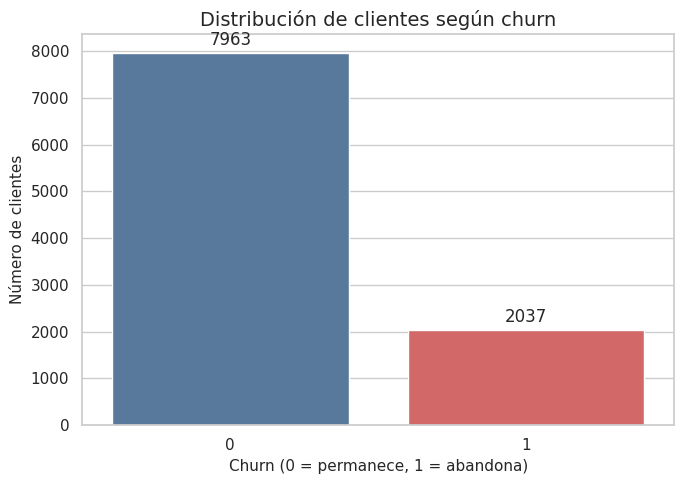

In [ ]:
# ============================================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 2.1 Configuración, estructura y calidad del dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from matplotlib.ticker import PercentFormatter

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Copia de trabajo para no alterar el dataset original
df_eda = df.copy()

# Variables esperadas
TARGET = "churn"
ID_COL = "customer_id"

required_columns = [
    "customer_id", "credit_score", "country", "gender", "age",
    "tenure", "balance", "products_number", "credit_card",
    "active_member", "estimated_salary", "churn"
]

missing_columns = sorted(set(required_columns) - set(df_eda.columns))

if missing_columns:
    raise ValueError(f"Faltan columnas esperadas en el dataset: {missing_columns}")

# Conversión defensiva de columnas numéricas
numeric_to_convert = [
    "customer_id", "credit_score", "age", "tenure", "balance",
    "products_number", "credit_card", "active_member",
    "estimated_salary", "churn"
]

for col in numeric_to_convert:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

# Limpieza básica de texto
for col in ["country", "gender"]:
    df_eda[col] = df_eda[col].astype("string").str.strip()

# ------------------------------------------------------------
# Resumen general del dataset
# ------------------------------------------------------------
print("=" * 75)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 75)

print(f"Número de filas: {df_eda.shape[0]:,}")
print(f"Número de columnas: {df_eda.shape[1]:,}")
print(f"Duplicados exactos: {df_eda.duplicated().sum():,}")

duplicados_sin_id = df_eda.drop(columns=[ID_COL]).duplicated().sum()
print(f"Registros repetidos excluyendo customer_id: {duplicados_sin_id:,}")

print("\nTipos de datos:")
display(df_eda.dtypes.to_frame(name="tipo_de_dato"))

# Tabla de calidad por variable
resumen_variables = pd.DataFrame({
    "tipo": df_eda.dtypes.astype(str),
    "no_nulos": df_eda.notna().sum(),
    "nulos": df_eda.isna().sum(),
    "porcentaje_nulos": (df_eda.isna().mean() * 100).round(2),
    "valores_unicos": df_eda.nunique(dropna=True)
}).sort_values(by="porcentaje_nulos", ascending=False)

print("\nCalidad de las variables:")
display(resumen_variables)

# ------------------------------------------------------------
# Distribución de la variable objetivo
# ------------------------------------------------------------
class_balance = (
    df_eda[TARGET]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("churn")
    .reset_index(name="cantidad_clientes")
)

class_balance["porcentaje"] = (
    class_balance["cantidad_clientes"] / class_balance["cantidad_clientes"].sum() * 100
).round(2)

class_balance["interpretacion"] = np.where(
    class_balance["churn"] == 1,
    "Cliente que abandona el banco",
    "Cliente que permanece en el banco"
)

print("\nDistribución de la variable objetivo:")
display(class_balance)

tasa_churn = df_eda[TARGET].mean()

print(f"\nTasa total de churn: {tasa_churn:.2%}")

if tasa_churn < 0.30:
    print("Diagnóstico: existe desbalance de clases moderado. "
          "En los modelos se recomienda utilizar estratificación y pesos de clase.")
else:
    print("Diagnóstico: la distribución de clases no presenta un desbalance severo.")

# Gráfico de churn
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=df_eda,
    x=TARGET,
    hue=TARGET,
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Distribución de clientes según churn")
plt.xlabel("Churn (0 = permanece, 1 = abandona)")
plt.ylabel("Número de clientes")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

ESTADÍSTICOS DESCRIPTIVOS DE VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,mediana,asimetria,curtosis
credit_score,"10,000.000",650.529,96.653,350.000,584.000,652.000,718.000,850.000,652.000,-0.072,-0.426
age,"10,000.000",38.922,10.488,18.000,32.000,37.000,44.000,92.000,37.000,1.011,1.395
tenure,"10,000.000",5.013,2.892,0.000,3.000,5.000,7.000,10.000,5.000,0.011,-1.165
balance,"10,000.000","76,485.889","62,397.405",0.000,0.000,"97,198.540","127,644.240","250,898.090","97,198.540",-0.141,-1.489
products_number,"10,000.000",1.530,0.582,1.000,1.000,1.000,2.000,4.000,1.000,0.746,0.583
estimated_salary,"10,000.000","100,090.240","57,510.493",11.580,"51,002.110","100,193.915","149,388.248","199,992.480","100,193.915",0.002,-1.182


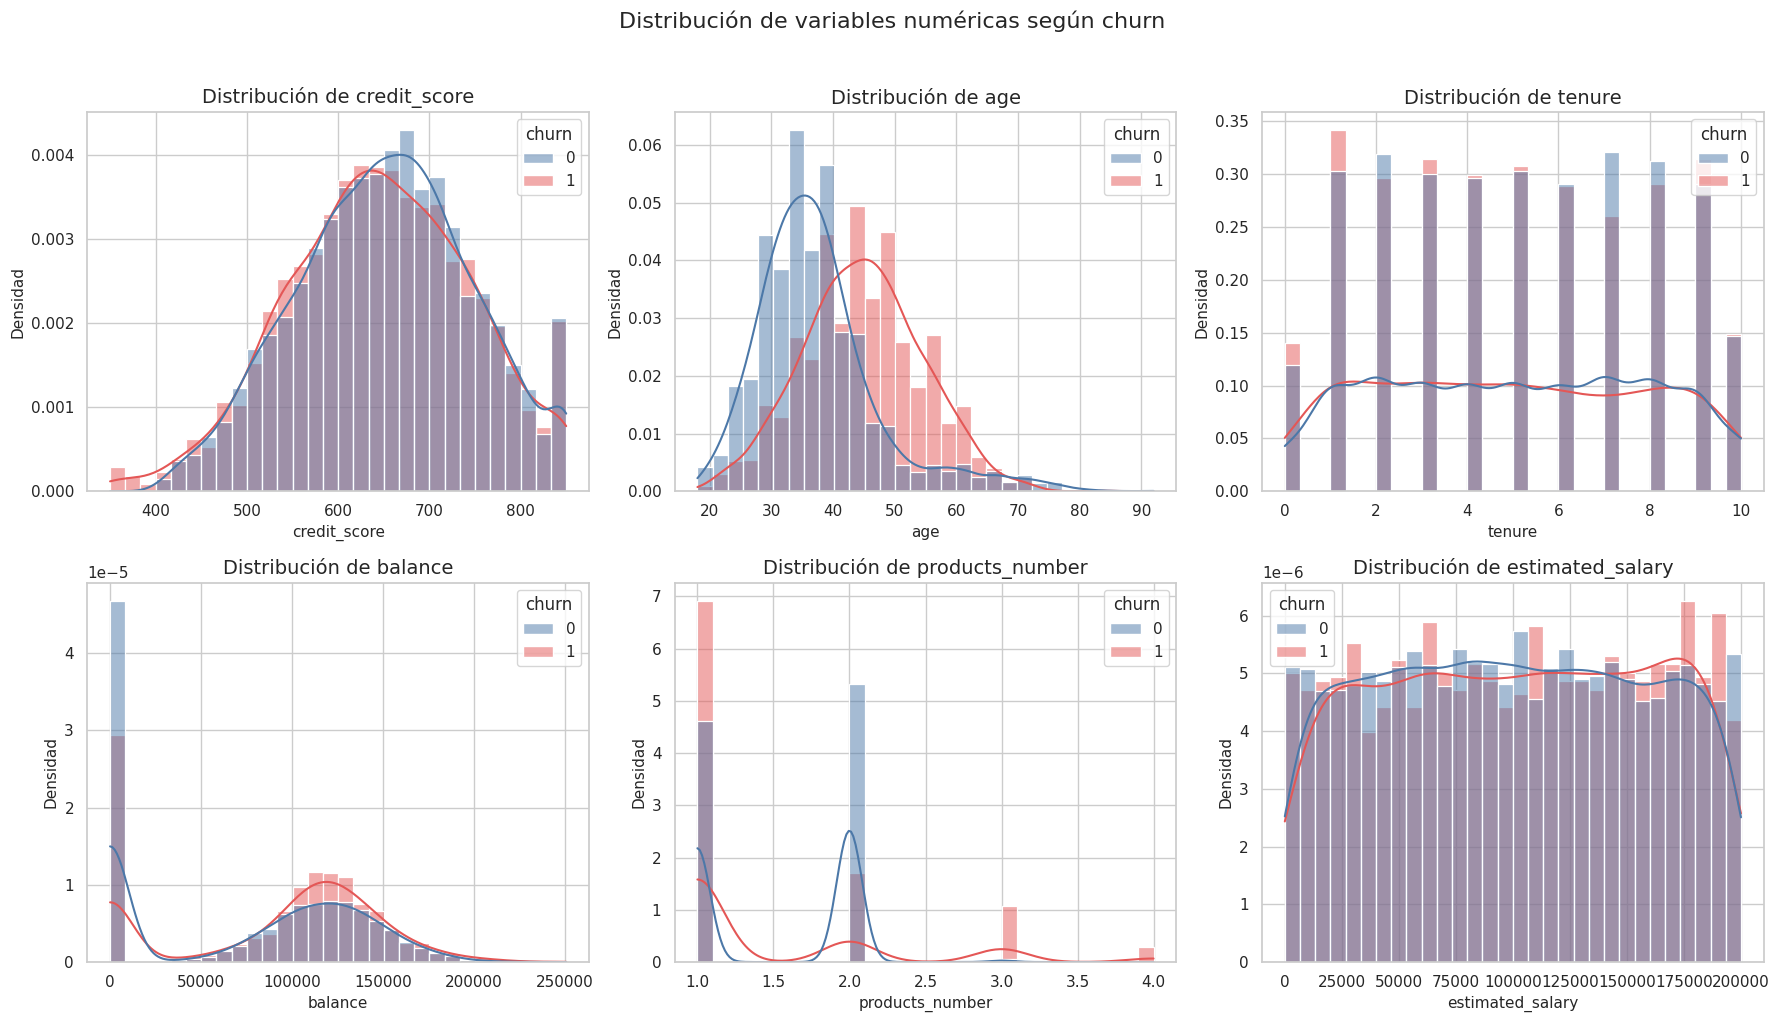

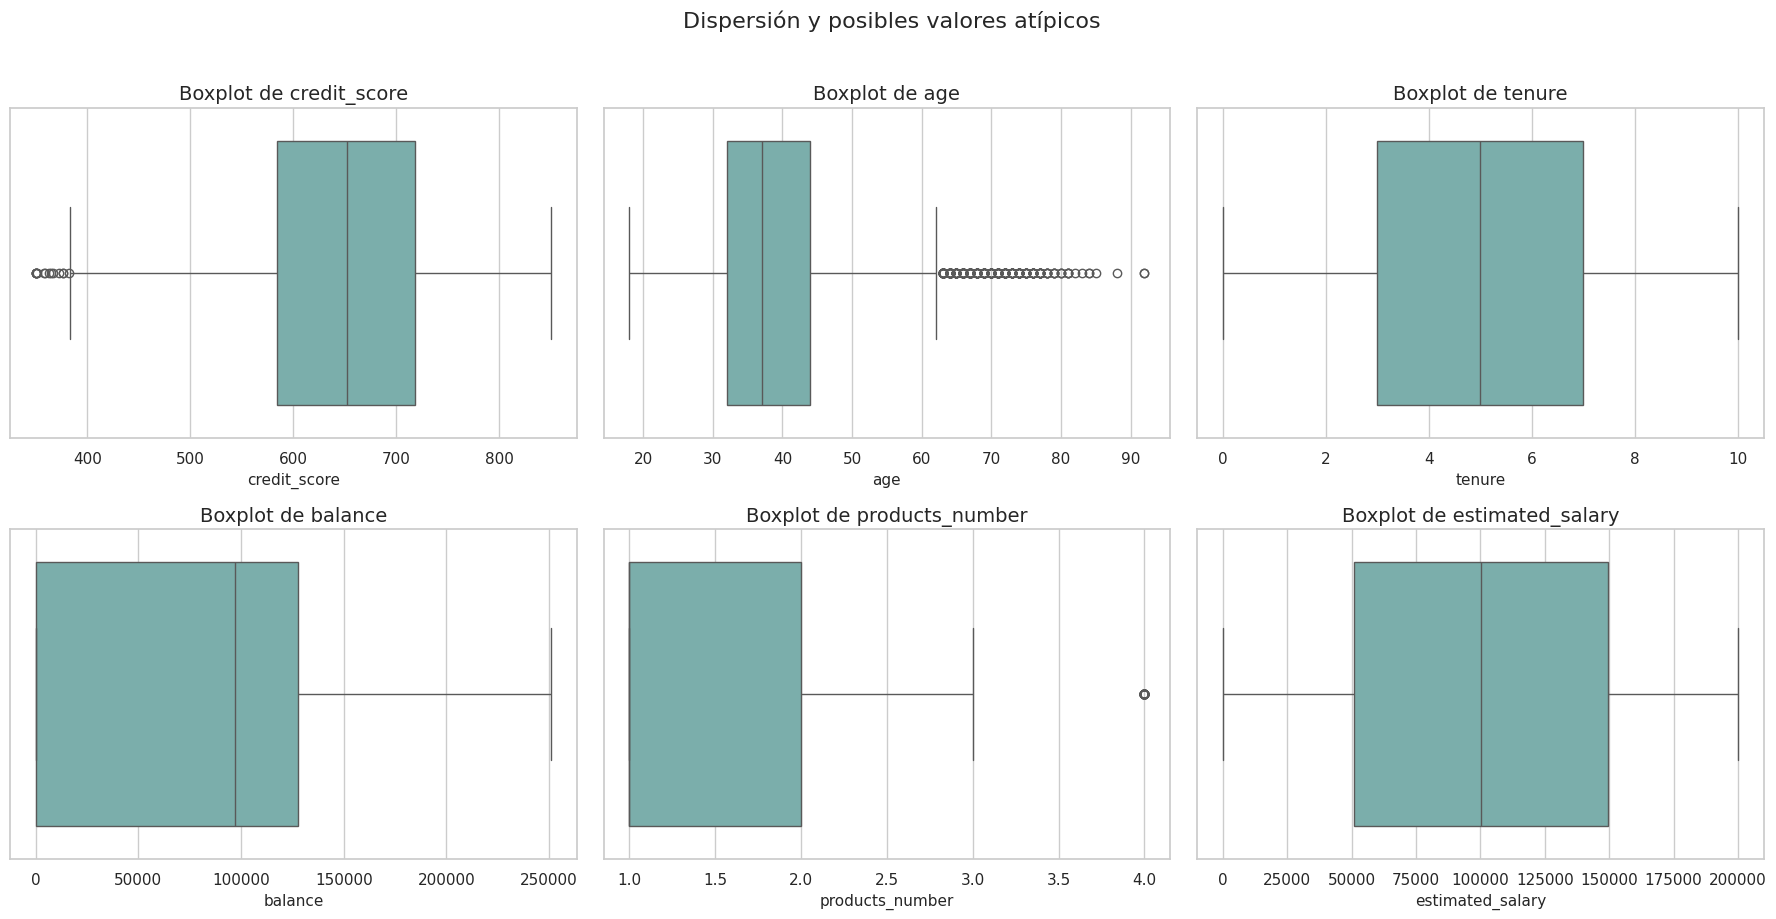


Distribución de country:


,country,cantidad,porcentaje
0,France,5014,50.140
1,Germany,2509,25.090
2,Spain,2477,24.770


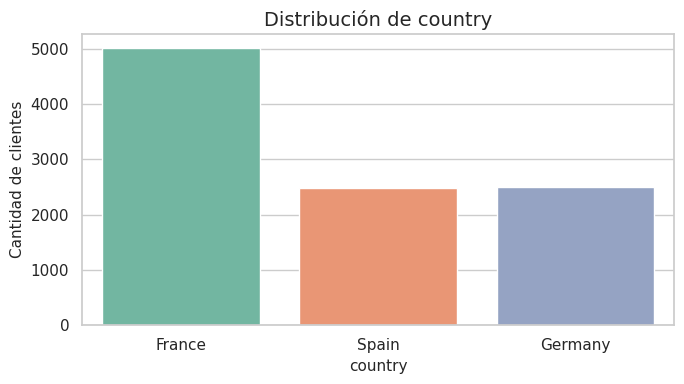


Distribución de gender:


,gender,cantidad,porcentaje
0,Male,5457,54.570
1,Female,4543,45.430


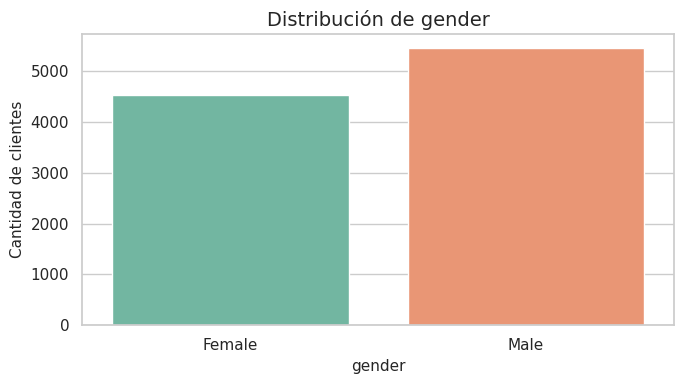


Distribución de credit_card:


,credit_card,cantidad,porcentaje
0,1,7055,70.550
1,0,2945,29.450


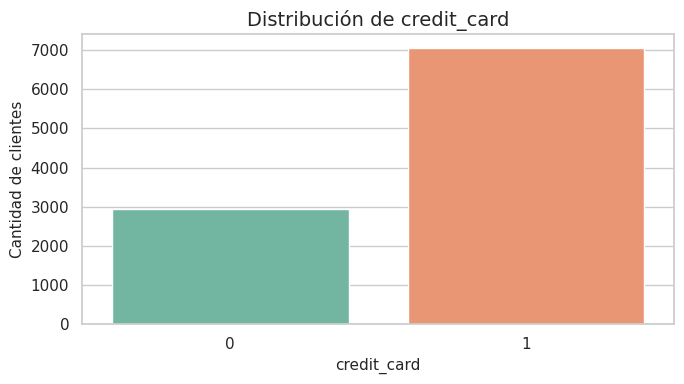


Distribución de active_member:


,active_member,cantidad,porcentaje
0,1,5151,51.510
1,0,4849,48.490


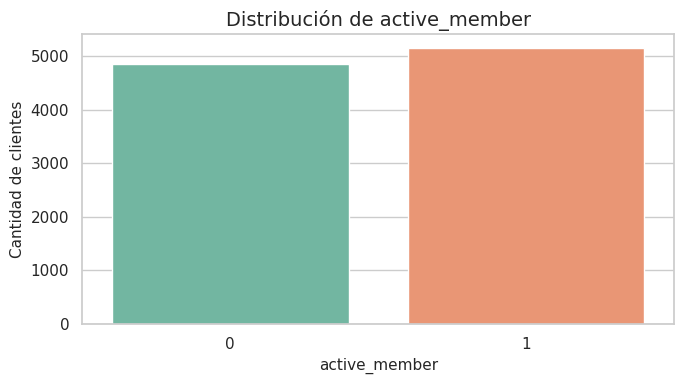

In [ ]:
# ============================================================
# 2.2 Análisis univariado
# Distribuciones numéricas y variables categóricas
# ============================================================

continuous_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

binary_features = [
    "credit_card",
    "active_member"
]

categorical_features = [
    "country",
    "gender"
]

# ------------------------------------------------------------
# Estadísticos descriptivos de variables numéricas
# ------------------------------------------------------------
print("=" * 75)
print("ESTADÍSTICOS DESCRIPTIVOS DE VARIABLES NUMÉRICAS")
print("=" * 75)

numeric_summary = df_eda[continuous_features].describe().T
numeric_summary["mediana"] = df_eda[continuous_features].median()
numeric_summary["asimetria"] = df_eda[continuous_features].skew()
numeric_summary["curtosis"] = df_eda[continuous_features].kurtosis()

display(numeric_summary.round(3))

# ------------------------------------------------------------
# Histogramas y densidades
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    sns.histplot(
        data=df_eda,
        x=col,
        hue=TARGET,
        bins=30,
        kde=True,
        stat="density",
        common_norm=False,
        palette=["#4C78A8", "#E45756"],
        ax=ax
    )
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")

plt.suptitle("Distribución de variables numéricas según churn", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Boxplots univariados: ayudan a visualizar dispersión y outliers
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    sns.boxplot(
        data=df_eda,
        x=col,
        color="#72B7B2",
        ax=ax
    )
    ax.set_title(f"Boxplot de {col}")
    ax.set_xlabel(col)

plt.suptitle("Dispersión y posibles valores atípicos", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Distribución de variables categóricas
# ------------------------------------------------------------
for col in categorical_features + binary_features:
    print(f"\nDistribución de {col}:")

    tabla_categoria = (
        df_eda[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="cantidad")
    )

    tabla_categoria["porcentaje"] = (
        tabla_categoria["cantidad"] / tabla_categoria["cantidad"].sum() * 100
    ).round(2)

    display(tabla_categoria)

    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=df_eda,
        x=col,
        hue=col,
        palette="Set2",
        legend=False
    )
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de clientes")
    plt.tight_layout()
    plt.show()

El análisis exploratorio indica que la base presenta una adecuada calidad de datos, sin valores faltantes ni registros duplicados. La variable objetivo muestra una tasa de churn de 20,37%, evidenciando un desbalance moderado que obliga a utilizar métricas adicionales a la accuracy y técnicas como estratificación y pesos de clase.

Entre las variables numéricas, la edad presenta una distribución sesgada a la derecha y una separación visual relevante entre clientes que permanecen y abandonan. El saldo exhibe una concentración importante en cero, lo que justifica la creación de una variable indicadora de saldo nulo. Por su parte, products_number es una variable discreta y no debe tratarse como un valor atípico tradicional, ya que sus categorías pueden reflejar perfiles de consumo distintos.

En las variables categóricas, Francia concentra aproximadamente la mitad de los clientes, mientras que Alemania y España representan cerca de un cuarto cada una. La variable active_member se perfila como especialmente relevante para el análisis de fuga, ya que la actividad del cliente representa una señal directa de vinculación con el banco. En consecuencia, el modelamiento debe considerar posibles relaciones no lineales e interacciones entre edad, saldo, actividad, cantidad de productos y país.

ANÁLISIS BIVARIADO: VARIABLES EXPLICATIVAS VS CHURN

Churn según country:


,country,clientes,tasa_churn,porcentaje_churn
1,Germany,2509,0.324,32.440
2,Spain,2477,0.167,16.670
0,France,5014,0.162,16.150


/tmp/ipykernel_696/2066153247.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


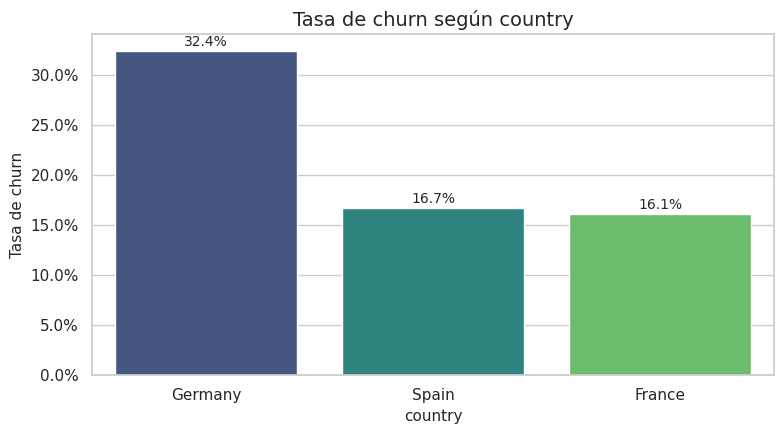


Churn según gender:


,gender,clientes,tasa_churn,porcentaje_churn
0,Female,4543,0.251,25.070
1,Male,5457,0.165,16.460


/tmp/ipykernel_696/2066153247.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


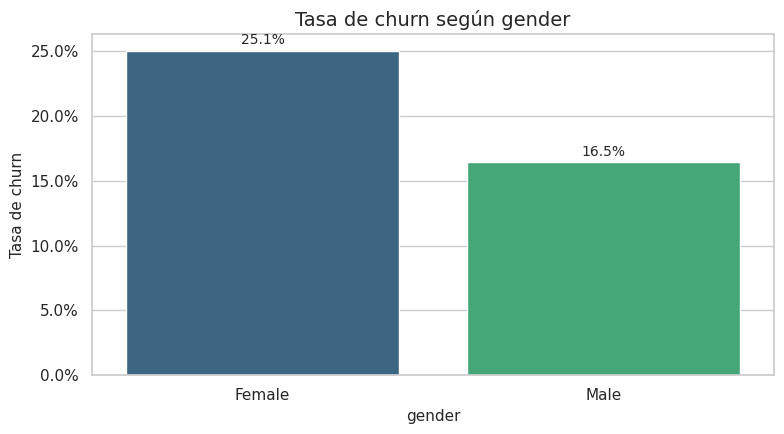


Churn según credit_card:


,credit_card,clientes,tasa_churn,porcentaje_churn
0,0,2945,0.208,20.810
1,1,7055,0.202,20.180


/tmp/ipykernel_696/2066153247.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


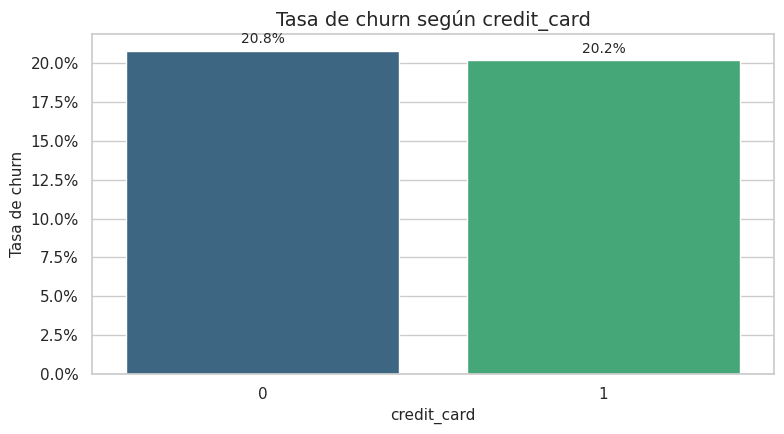


Churn según active_member:


,active_member,clientes,tasa_churn,porcentaje_churn
0,0,4849,0.269,26.850
1,1,5151,0.143,14.270


/tmp/ipykernel_696/2066153247.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


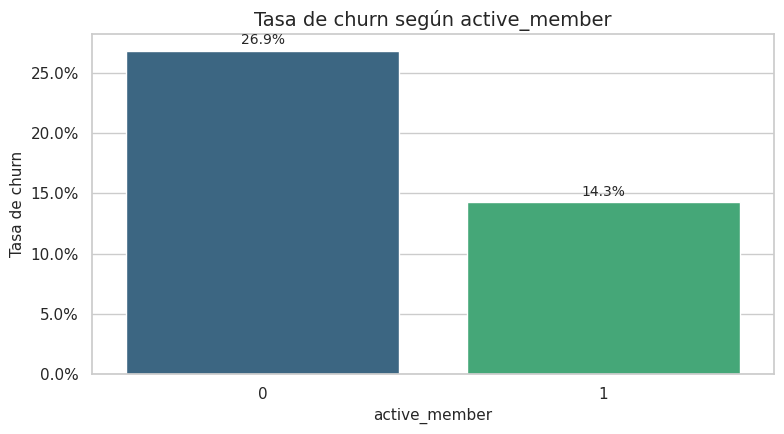


Churn según products_number:


,products_number,clientes,tasa_churn,porcentaje_churn
3,4,60,1.000,100.000
2,3,266,0.827,82.710
0,1,5084,0.277,27.710
1,2,4590,0.076,7.580


/tmp/ipykernel_696/2066153247.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


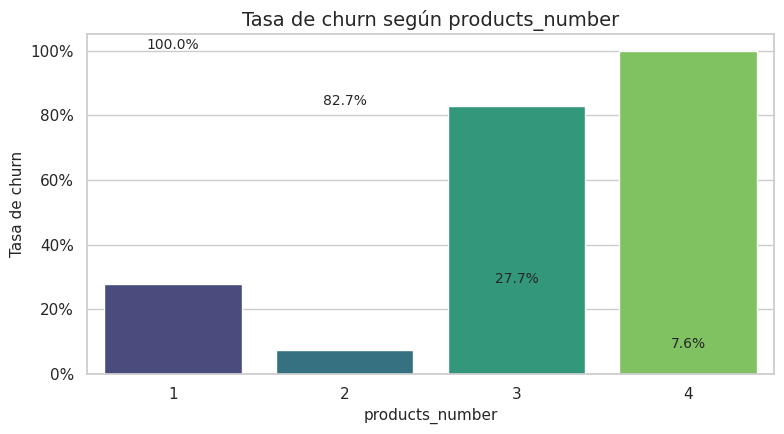


Comparación de variables numéricas según churn:


credit_score                    age               tenure               \
              mean  median     std   mean median    std   mean median   std   
churn                                                                         
0          651.853 653.000  95.654 37.408 36.000 10.125  5.033  5.000 2.881   
1          645.351 646.000 100.322 44.838 45.000  9.762  4.933  5.000 2.936   

         balance                        products_number               \
            mean      median        std            mean median   std   
churn                                                                  
0     72,745.297  92,072.680 62,848.041           1.544  2.000 0.510   
1     91,108.539 109,349.290 58,360.795           1.475  1.000 0.802   

      estimated_salary                         
                  mean      median        std  
churn                                          
0           99,738.392  99,645.040 57,405.587  
1          101,465.678 102,460.840 57,912.418

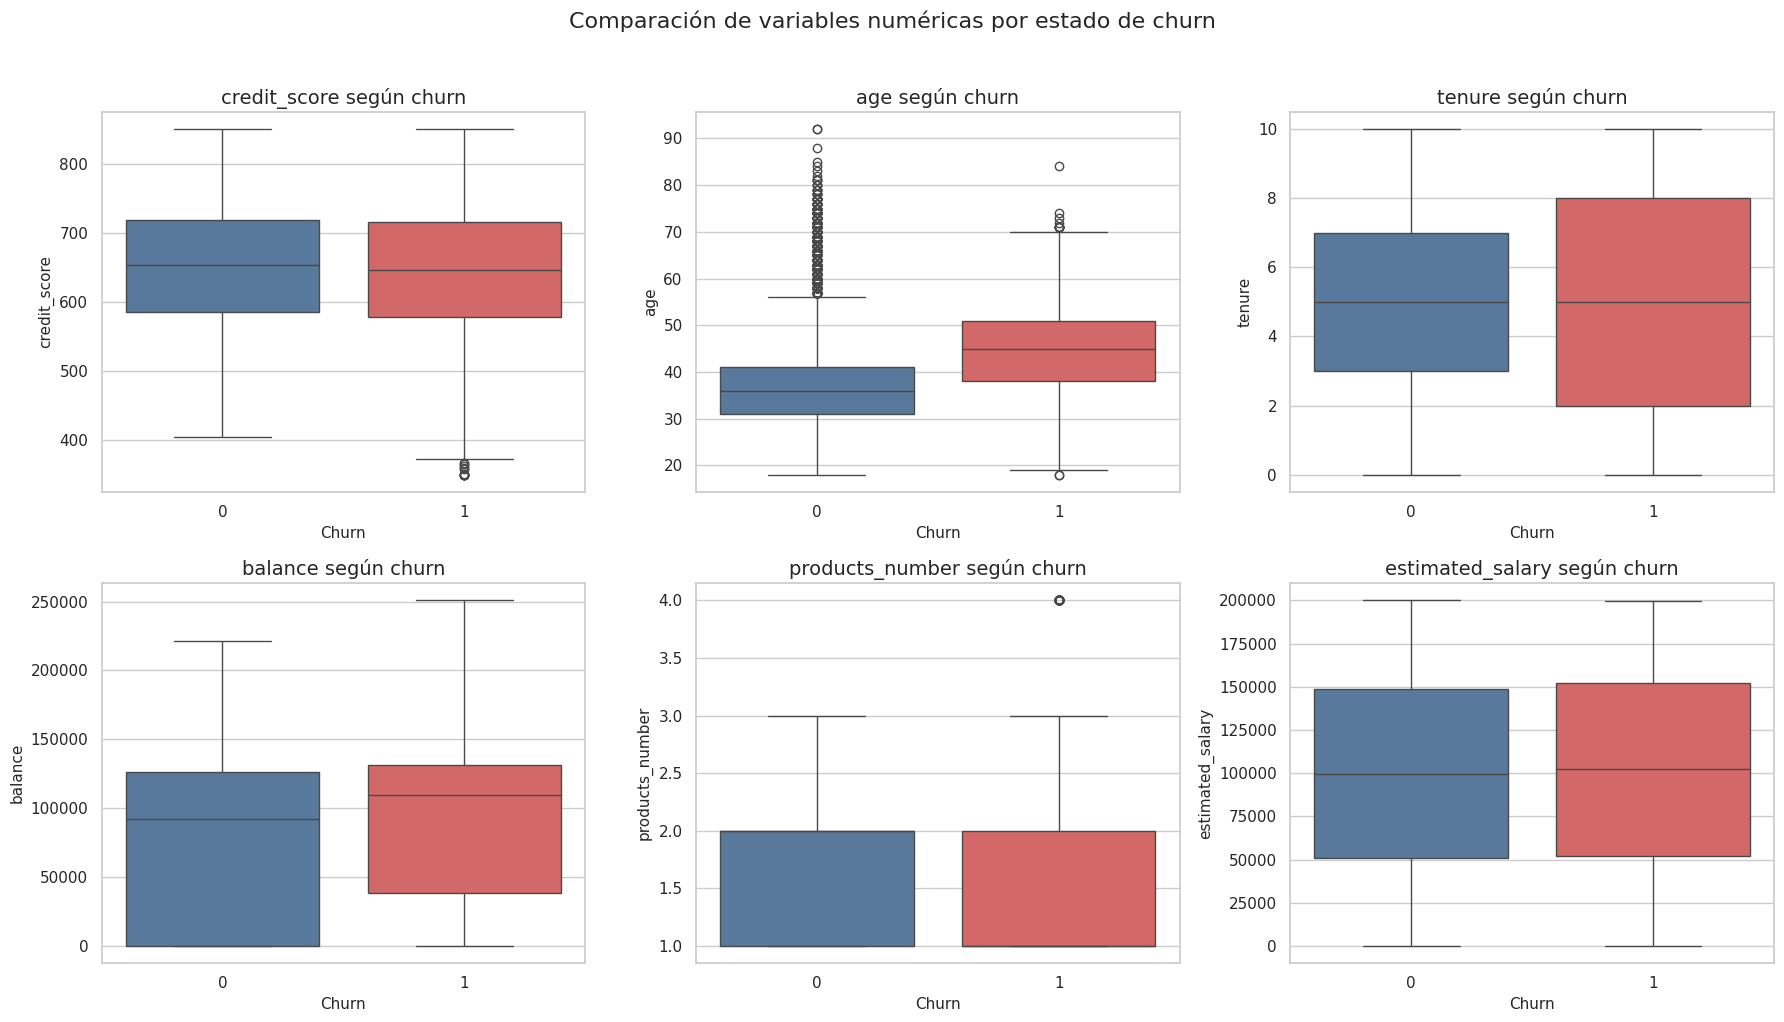

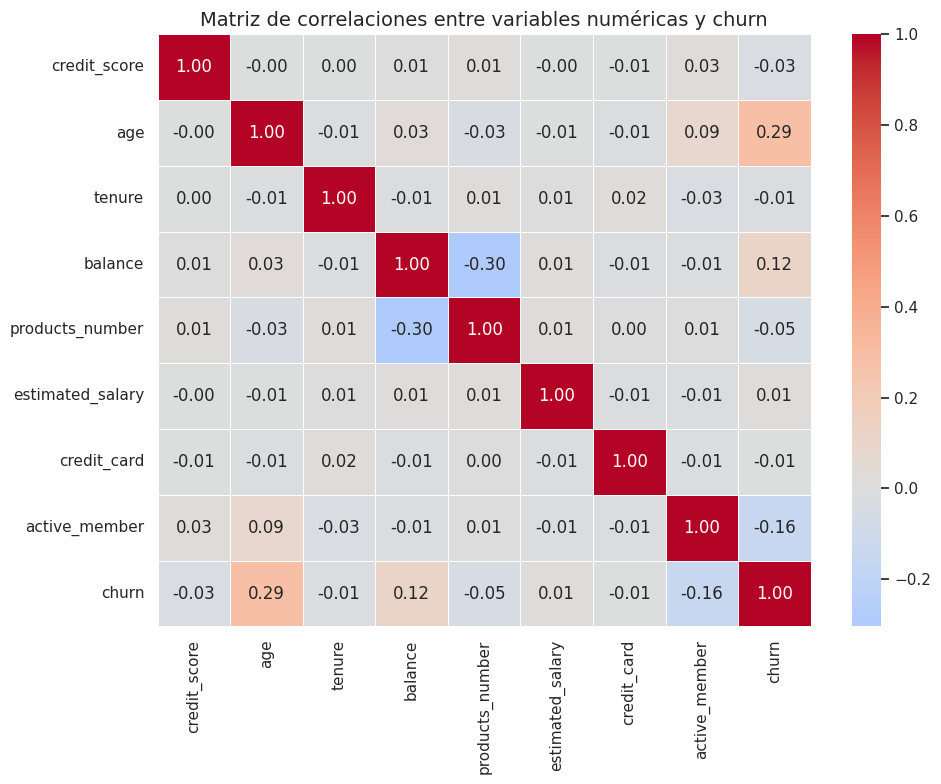


Variables numéricas ordenadas según relación lineal con churn:


,correlacion_con_churn,correlacion_abs
age,0.285,0.285
active_member,-0.156,0.156
balance,0.118,0.118
products_number,-0.048,0.048
credit_score,-0.027,0.027
tenure,-0.014,0.014
estimated_salary,0.012,0.012
credit_card,-0.007,0.007


/tmp/ipykernel_696/2066153247.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


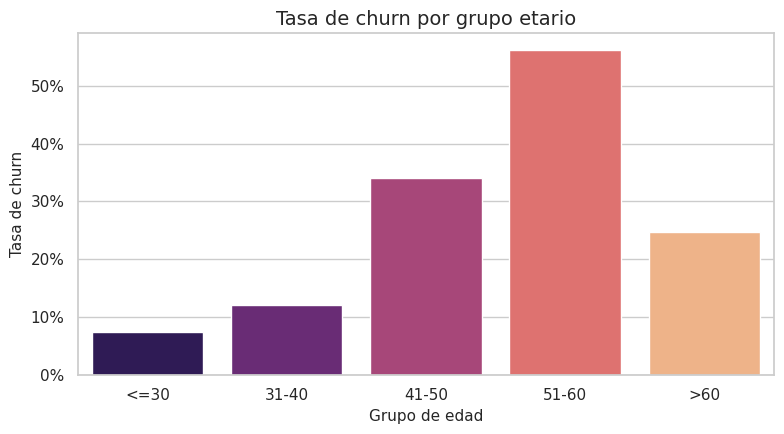

,grupo_edad,clientes,tasa_churn
0,<=30,1968,0.075
1,31-40,4451,0.121
2,41-50,2320,0.340
3,51-60,797,0.562
4,>60,464,0.248


In [ ]:
# ============================================================
# 2.3 Análisis bivariado
# Relación entre predictores y variable churn
# ============================================================

print("=" * 75)
print("ANÁLISIS BIVARIADO: VARIABLES EXPLICATIVAS VS CHURN")
print("=" * 75)

# ------------------------------------------------------------
# Churn por variables categóricas y binarias
# ------------------------------------------------------------
segment_features = categorical_features + binary_features + ["products_number"]

for col in segment_features:

    resumen_segmento = (
        df_eda
        .groupby(col, dropna=False)[TARGET]
        .agg(
            clientes="count",
            tasa_churn="mean"
        )
        .reset_index()
        .sort_values("tasa_churn", ascending=False)
    )

    resumen_segmento["tasa_churn"] = resumen_segmento["tasa_churn"].round(4)
    resumen_segmento["porcentaje_churn"] = (
        resumen_segmento["tasa_churn"] * 100
    ).round(2)

    print(f"\nChurn según {col}:")
    display(resumen_segmento)

    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(
        data=resumen_segmento,
        x=col,
        y="tasa_churn",
        palette="viridis"
    )

    plt.title(f"Tasa de churn según {col}")
    plt.xlabel(col)
    plt.ylabel("Tasa de churn")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

    for i, row in resumen_segmento.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["tasa_churn"] + 0.005,
            f'{row["porcentaje_churn"]:.1f}%',
            ha="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Resumen numérico por estado de churn
# ------------------------------------------------------------
print("\nComparación de variables numéricas según churn:")
resumen_por_churn = (
    df_eda
    .groupby(TARGET)[continuous_features]
    .agg(["mean", "median", "std"])
    .round(3)
)

display(resumen_por_churn)

# ------------------------------------------------------------
# Boxplots numéricos separados por churn
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    sns.boxplot(
        data=df_eda,
        x=TARGET,
        y=col,
        hue=TARGET,
        palette=["#4C78A8", "#E45756"],
        legend=False,
        ax=ax
    )

    ax.set_title(f"{col} según churn")
    ax.set_xlabel("Churn")
    ax.set_ylabel(col)

plt.suptitle("Comparación de variables numéricas por estado de churn", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Correlaciones con churn
# ------------------------------------------------------------
correlation_features = continuous_features + binary_features + [TARGET]

correlation_matrix = df_eda[correlation_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de correlaciones entre variables numéricas y churn")
plt.tight_layout()
plt.show()

corr_with_churn = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("correlacion_con_churn")
)

corr_with_churn["correlacion_abs"] = corr_with_churn["correlacion_con_churn"].abs()

print("\nVariables numéricas ordenadas según relación lineal con churn:")
display(corr_with_churn.round(4))

# ------------------------------------------------------------
# Visualización: tasa de churn por grupos de edad
# ------------------------------------------------------------
df_eda["grupo_edad"] = pd.cut(
    df_eda["age"],
    bins=[0, 30, 40, 50, 60, 120],
    labels=["<=30", "31-40", "41-50", "51-60", ">60"]
)

churn_by_age = (
    df_eda
    .groupby("grupo_edad", observed=False)[TARGET]
    .agg(clientes="count", tasa_churn="mean")
    .reset_index()
)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=churn_by_age,
    x="grupo_edad",
    y="tasa_churn",
    palette="magma"
)
plt.title("Tasa de churn por grupo etario")
plt.xlabel("Grupo de edad")
plt.ylabel("Tasa de churn")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

display(churn_by_age.round(4))

El análisis bivariado revela que las variables más asociadas con churn son país, edad, actividad del cliente, saldo y número de productos contratados. Alemania presenta una tasa de abandono de 32,44%, muy superior a Francia y España, cercanas al 16%. Asimismo, los clientes inactivos muestran una tasa de churn de 26,85%, frente a 14,27% en clientes activos, lo que refuerza la importancia de la vinculación y uso efectivo de los servicios bancarios.

La edad exhibe una relación relevante y no lineal con la variable objetivo. El churn aumenta marcadamente entre los 41 y 60 años, alcanzando 56,2% en el segmento de 51 a 60 años. Por su parte, los clientes que abandonan presentan saldos promedio superiores, lo que sugiere que la fuga puede implicar pérdida de clientes de valor financiero relevante.

El número de productos presenta un patrón no lineal: los clientes con dos productos tienen la menor tasa de churn, mientras que aquellos con tres o cuatro productos concentran tasas elevadas, aunque estos últimos grupos presentan tamaños muestrales reducidos. Por esta razón, la variable debe ser tratada categóricamente o agrupada para evitar conclusiones inestables y sobreajuste en los modelos.

Finalmente, el análisis de correlación muestra que la edad, la actividad del cliente y el saldo tienen las relaciones lineales más relevantes con churn. Sin embargo, variables con baja correlación lineal, como número de productos, pueden mantener alta utilidad predictiva debido a relaciones no lineales e interacciones con otras variables.

In [ ]:
# ============================================================
# 2.4 Detección de valores atípicos mediante método IQR
# ============================================================

print("=" * 75)
print("DETECCIÓN DE VALORES ATÍPICOS CON MÉTODO IQR")
print("=" * 75)

outlier_results = []
outlier_mask = pd.DataFrame(index=df_eda.index)

for col in continuous_features:

    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)
    outlier_mask[col] = mask

    outlier_results.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": lower_bound,
        "limite_superior": upper_bound,
        "cantidad_outliers": int(mask.sum()),
        "porcentaje_outliers": round(mask.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_results).sort_values(
    "porcentaje_outliers",
    ascending=False
)

display(outlier_summary.round(3))

total_rows_with_outliers = outlier_mask.any(axis=1).sum()
percentage_rows_with_outliers = outlier_mask.any(axis=1).mean() * 100

print(f"\nClientes con al menos un valor atípico: {total_rows_with_outliers:,}")
print(f"Porcentaje de clientes con al menos un valor atípico: {percentage_rows_with_outliers:.2f}%")

# Muestra de registros con valores atípicos
sample_outliers = df_eda.loc[
    outlier_mask.any(axis=1),
    continuous_features + [TARGET]
].head(10)

print("\nMuestra de registros identificados con al menos un posible valor atípico:")
display(sample_outliers)

# ------------------------------------------------------------
# Decisión metodológica automática
# ------------------------------------------------------------
missing_total = df_eda.isna().sum().sum()

if missing_total == 0:
    missing_decision = (
        "No se observan valores faltantes. De todas formas, se utilizará "
        "imputación dentro del pipeline para que el modelo sea robusto y reproducible."
    )
else:
    missing_decision = (
        "Existen valores faltantes. Se utilizará mediana para variables numéricas "
        "y moda para variables categóricas, ya que son métodos robustos y simples."
    )

display(Markdown(f"""
## Decisiones de preparación de datos

**1. Valores faltantes:**
{missing_decision}

**2. Valores atípicos:**
Los valores atípicos no se eliminarán automáticamente, porque en datos bancarios un saldo,
salario, edad o puntaje de crédito extremo puede corresponder a un cliente real y relevante.
En lugar de eliminarlos, se utilizará `RobustScaler`, que emplea mediana e IQR y reduce la
influencia de valores extremos en modelos sensibles a escalas, como la regresión logística.

**3. Variable customer_id:**
Se eliminará antes del entrenamiento porque es solo un identificador. No representa un
atributo económico, financiero ni conductual del cliente, y puede inducir patrones espurios.

**4. Variable balance:**
Se mantendrá el saldo original y se creará una variable adicional llamada `balance_zero`.
Esta identificará a clientes con saldo igual a cero, ya que ese grupo puede tener un
comportamiento de churn distinto y relevante para el negocio.

**5. Variables categóricas:**
`country` y `gender` se transformarán mediante One-Hot Encoding para que los modelos
puedan utilizar esta información sin imponer un orden artificial entre categorías.

**6. Desbalance de clases:**
Se utilizará separación estratificada entre entrenamiento y prueba. Además, en modelos
que lo permitan se aplicarán pesos de clase balanceados para dar mayor relevancia a los
clientes que abandonan el banco.
"""))

DETECCIÓN DE VALORES ATÍPICOS CON MÉTODO IQR


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
1,age,32.000,44.000,12.000,14.000,62.000,359,3.590
4,products_number,1.000,2.000,1.000,-0.500,3.500,60,0.600
0,credit_score,584.000,718.000,134.000,383.000,919.000,15,0.150
2,tenure,3.000,7.000,4.000,-3.000,13.000,0,0.000
3,balance,0.000,"127,644.240","127,644.240","-191,466.360","319,110.600",0,0.000
5,estimated_salary,"51,002.110","149,388.248","98,386.138","-96,577.096","296,967.454",0,0.000



Clientes con al menos un valor atípico: 432
Porcentaje de clientes con al menos un valor atípico: 4.32%

Muestra de registros identificados con al menos un posible valor atípico:


,credit_score,age,tenure,balance,products_number,estimated_salary,churn
7,376,29,4,"115,046.740",4,"119,346.880",1
58,511,66,4,0.000,1,"1,643.110",1
70,738,58,2,"133,745.440",4,"28,373.860",1
85,652,75,10,0.000,2,"114,675.750",0
104,670,65,1,0.000,1,"177,655.680",1
158,646,73,6,"97,259.250",1,"104,719.660",0
181,510,65,2,0.000,2,"48,071.610",0
230,673,72,1,0.000,2,"111,981.190",0
234,585,67,5,"113,978.970",2,"93,146.110",0
243,659,67,6,"117,411.600",1,"45,071.090",1



## Decisiones de preparación de datos

**1. Valores faltantes:**  
No se observan valores faltantes. De todas formas, se utilizará imputación dentro del pipeline para que el modelo sea robusto y reproducible.

**2. Valores atípicos:**  
Los valores atípicos no se eliminarán automáticamente, porque en datos bancarios un saldo,
salario, edad o puntaje de crédito extremo puede corresponder a un cliente real y relevante.
En lugar de eliminarlos, se utilizará `RobustScaler`, que emplea mediana e IQR y reduce la
influencia de valores extremos en modelos sensibles a escalas, como la regresión logística.

**3. Variable customer_id:**  
Se eliminará antes del entrenamiento porque es solo un identificador. No representa un
atributo económico, financiero ni conductual del cliente, y puede inducir patrones espurios.

**4. Variable balance:**  
Se mantendrá el saldo original y se creará una variable adicional llamada `balance_zero`.
Esta identificará a clientes con saldo igual a cero, ya que ese grupo puede tener un
comportamiento de churn distinto y relevante para el negocio.

**5. Variables categóricas:**  
`country` y `gender` se transformarán mediante One-Hot Encoding para que los modelos
puedan utilizar esta información sin imponer un orden artificial entre categorías.

**6. Desbalance de clases:**  
Se utilizará separación estratificada entre entrenamiento y prueba. Además, en modelos
que lo permitan se aplicarán pesos de clase balanceados para dar mayor relevancia a los
clientes que abandonan el banco.


La detección de valores atípicos mediante el método IQR identificó 432 clientes con al menos una observación extrema, equivalente al 4,32% de la muestra. La mayor parte de estos casos se concentra en la variable edad, seguida por clientes con cuatro productos y algunos puntajes crediticios bajos.

No se eliminaron automáticamente estos registros, ya que en el contexto bancario representan perfiles reales y potencialmente relevantes. Por ejemplo, clientes de mayor edad, con saldo cero, bajo puntaje crediticio o múltiples productos pueden presentar comportamientos de churn distintos y aportar información predictiva valiosa.

En consecuencia, se optó por mantener las observaciones y utilizar RobustScaler para reducir la influencia de valores extremos en modelos sensibles a escala. Además, se preservará el saldo original junto con una variable indicadora de saldo cero, y el número de productos será tratado como una variable categórica debido a su relación no lineal con el churn.



### 3. Preparación de los Datos

- Codifique las variables categóricas (p.ej., *One-Hot Encoding*).
- Escale las variables numéricas cuando sea necesario.
- Divida los datos en conjuntos de entrenamiento y prueba utilizando **estratificación**.
- Evalúe si existe **desbalance de clases** y cómo lo abordará (p.ej., SMOTE, pesos de clase).



In [ ]:
# ============================================================
# 3. PREPARACIÓN DE DATOS PARA MACHINE LEARNING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# Copia final para modelamiento
# ------------------------------------------------------------
df_model = df_eda.copy()

# Eliminar variable auxiliar usada solo para EDA
df_model = df_model.drop(columns=["grupo_edad"], errors="ignore")

# Eliminar duplicados exactos, si existieran
df_model = df_model.drop_duplicates().copy()

# Crear variable estratégica:
# 1 si el cliente no posee saldo; 0 si posee saldo.
df_model["balance_zero"] = (df_model["balance"] == 0).astype(int)

# Eliminar identificador único
df_model = df_model.drop(columns=[ID_COL])

# Definir X e y
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(int)

# Variables finales para el preprocesamiento
numeric_features_model = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

binary_features_model = [
    "credit_card",
    "active_member",
    "balance_zero"
]

categorical_features_model = [
    "country",
    "gender"
]

# ------------------------------------------------------------
# División Train/Test con estratificación
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 75)
print("DIVISIÓN DE ENTRENAMIENTO Y PRUEBA")
print("=" * 75)

print(f"Observaciones de entrenamiento: {X_train.shape[0]:,}")
print(f"Observaciones de prueba: {X_test.shape[0]:,}")
print(f"Porcentaje churn en entrenamiento: {y_train.mean():.2%}")
print(f"Porcentaje churn en prueba: {y_test.mean():.2%}")

# ------------------------------------------------------------
# Evaluación del desbalance y pesos de clase
# ------------------------------------------------------------
classes = np.array(sorted(y_train.unique()))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

class_summary_train = (
    y_train
    .value_counts()
    .sort_index()
    .rename_axis("churn")
    .reset_index(name="cantidad")
)

class_summary_train["porcentaje"] = (
    class_summary_train["cantidad"] / class_summary_train["cantidad"].sum() * 100
).round(2)

display(class_summary_train)

print("\nPesos de clase para futuros modelos:")
print(class_weights)

# ------------------------------------------------------------
# Pipeline numérico:
# - Mediana si existen nulos.
# - RobustScaler para reducir impacto de outliers.
# ------------------------------------------------------------
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Pipeline de variables binarias
binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Pipeline categórico:
# - Moda para faltantes.
# - One-Hot Encoding.
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    ))
])

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", numeric_pipeline, numeric_features_model),
        ("binarias", binary_pipeline, binary_features_model),
        ("categoricas", categorical_pipeline, categorical_features_model)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Ajustar solo con datos de entrenamiento
# Esto evita data leakage.
# ------------------------------------------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Nombres de variables luego del preprocesamiento
feature_names = preprocessor.get_feature_names_out()

# Convertir a DataFrame para visualizar los resultados
X_train_ready = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_ready = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

# ------------------------------------------------------------
# Validaciones finales
# ------------------------------------------------------------
print("=" * 75)
print("VALIDACIÓN FINAL DEL PREPROCESAMIENTO")
print("=" * 75)

print(f"Shape X_train original: {X_train.shape}")
print(f"Shape X_train procesado: {X_train_ready.shape}")
print(f"Shape X_test original: {X_test.shape}")
print(f"Shape X_test procesado: {X_test_ready.shape}")

print(f"\nValores faltantes en train procesado: {X_train_ready.isna().sum().sum()}")
print(f"Valores faltantes en test procesado: {X_test_ready.isna().sum().sum()}")

assert X_train_ready.isna().sum().sum() == 0, "Aún existen nulos en train"
assert X_test_ready.isna().sum().sum() == 0, "Aún existen nulos en test"

print("\nPrimeras filas del dataset procesado para entrenamiento:")
display(X_train_ready.head())

# Datos que se utilizarán en las siguientes secciones de modelos
print("\nVariables listas para modelamiento:")
print(list(X_train_ready.columns))

DIVISIÓN DE ENTRENAMIENTO Y PRUEBA
Observaciones de entrenamiento: 8,000
Observaciones de prueba: 2,000
Porcentaje churn en entrenamiento: 20.38%
Porcentaje churn en prueba: 20.35%


,churn,cantidad,porcentaje
0,0,6370,79.620
1,1,1630,20.380



Pesos de clase para futuros modelos:
{np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}
VALIDACIÓN FINAL DEL PREPROCESAMIENTO
Shape X_train original: (8000, 11)
Shape X_train procesado: (8000, 12)
Shape X_test original: (2000, 11)
Shape X_test procesado: (2000, 12)

Valores faltantes en train procesado: 0
Valores faltantes en test procesado: 0

Primeras filas del dataset procesado para entrenamiento:


,credit_score,age,tenure,balance,products_number,estimated_salary,credit_card,active_member,balance_zero,country_Germany,country_Spain,gender_Male
2151,0.759,1.667,0.400,-0.760,0.000,0.614,1.000,0.000,1.000,0.000,0.000,1.000
8392,0.654,-0.417,-0.400,0.040,0.000,-0.363,1.000,0.000,0.000,1.000,0.000,1.000
5006,0.774,0.000,-1.000,0.132,1.000,0.183,1.000,1.000,0.000,1.000,0.000,0.000
4117,-0.684,0.000,0.000,-0.760,1.000,-0.167,1.000,0.000,1.000,0.000,0.000,1.000
7182,0.301,1.000,0.200,0.106,1.000,0.082,0.000,1.000,0.000,1.000,0.000,1.000



Variables listas para modelamiento:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'credit_card', 'active_member', 'balance_zero', 'country_Germany', 'country_Spain', 'gender_Male']


La preparación de datos incluyó la eliminación de la variable customer_id, debido a que corresponde a un identificador único sin valor predictivo directo. Las variables categóricas fueron transformadas mediante One-Hot Encoding, utilizando Francia y Female como categorías de referencia.

Las variables numéricas fueron escaladas mediante RobustScaler, método adecuado para reducir la influencia de posibles valores extremos sin eliminar observaciones reales. Además, se incorporó la variable balance_zero para identificar clientes sin saldo, ya que este grupo puede reflejar un comportamiento financiero y de vinculación diferente.

Debido al desbalance moderado de la variable objetivo, se aplicó una división estratificada entre entrenamiento y prueba y se utilizaron pesos de clase balanceados. Finalmente, el número de productos se transformó en una variable categórica agrupada, dado que el análisis exploratorio evidenció una relación no lineal entre la cantidad de productos y el riesgo de abandono.



### 4. Fase de Modelado

Deberá construir **cuatro modelos de clasificación**:

#### 4.1 Regresión Logística
- Utilícela como **modelo de referencia (*baseline*)**.
- Explique los coeficientes e interprételos en términos de probabilidad de *churn*.

#### 4.2 Árbol de Decisión
- Realice ajuste de hiperparámetros (p.ej., `max_depth`, `min_samples_split`, `min_samples_leaf`).

#### 4.3 Random Forest
- Utilice búsqueda aleatoria o exhaustiva de hiperparámetros (p.ej., número de árboles, profundidad, tamaño de hoja).

#### 4.4 Gradient Boosting
- Ajuste la tasa de aprendizaje, la profundidad y el número de estimadores.
- Argumente por qué el *boosting* podría superar a los demás modelos.



4. FASE DE MODELADO
Distribución churn en entrenamiento: 20.38%
Pesos de clase utilizados: {np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}

MODELO 1: REGRESIÓN LOGÍSTICA ENTRENADO

Variables más influyentes según Regresión Logística:


,variable,coeficiente,odds_ratio,impacto,magnitud_abs
1,age,0.913,2.493,Aumenta probabilidad de churn,0.913
7,active_member,-0.883,0.413,Reduce probabilidad de churn,0.883
9,country_Germany,0.811,2.250,Aumenta probabilidad de churn,0.811
11,gender_Male,-0.544,0.580,Reduce probabilidad de churn,0.544
3,balance,0.255,1.290,Aumenta probabilidad de churn,0.255
8,balance_zero,-0.124,0.883,Reduce probabilidad de churn,0.124
0,credit_score,-0.119,0.887,Reduce probabilidad de churn,0.119
4,products_number,-0.096,0.908,Reduce probabilidad de churn,0.096
5,estimated_salary,0.085,1.089,Aumenta probabilidad de churn,0.085
6,credit_card,-0.068,0.934,Reduce probabilidad de churn,0.068


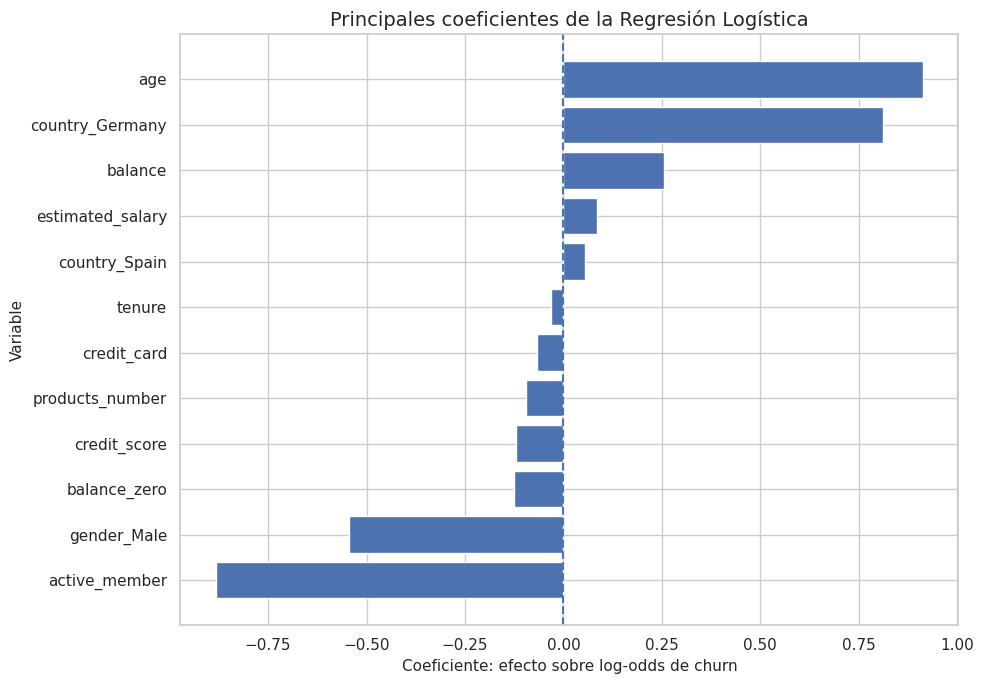


### Interpretación de la Regresión Logística

- Un **coeficiente positivo** se asocia con una mayor probabilidad de que el cliente abandone el banco.
- Un **coeficiente negativo** se asocia con una menor probabilidad de churn.
- El indicador `odds_ratio` muestra cuánto cambian las probabilidades relativas de churn.
- Por ejemplo, un `odds_ratio = 1,30` implica que las odds de churn aumentan aproximadamente 30% ante un aumento unitario de la variable, manteniendo las demás constantes.
- Como las variables numéricas fueron escaladas con `RobustScaler`, sus coeficientes deben interpretarse considerando cambios relativos a su dispersión robusta.


Fitting 5 folds for each of 576 candidates, totalling 2880 fits

MODELO 2: ÁRBOL DE DECISIÓN ENTRENADO
Mejores hiperparámetros:
{'model__ccp_alpha': 0.0005, 'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
Mejor ROC-AUC promedio validación cruzada: 0.8374
Fitting 5 folds for each of 25 candidates, totalling 125 fits

MODELO 3: RANDOM FOREST ENTRENADO
Mejores hiperparámetros:
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 5, 'model__min_samples_split': 14, 'model__n_estimators': 290}
Mejor ROC-AUC promedio validación cruzada: 0.8616
Fitting 5 folds for each of 25 candidates, totalling 125 fits

MODELO 4: GRADIENT BOOSTING ENTRENADO
Mejores hiperparámetros:
{'model__learning_rate': np.float64(0.013940305267157801), 'model__max_depth': 4, 'model__max_features': None, 'model__min_samples_leaf': 3, 'model__min_samples_split': 8, 'model__n_estima


## ¿Por qué Gradient Boosting podría superar a otros modelos?

Gradient Boosting construye árboles de forma secuencial. Cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores. Esto puede ser especialmente útil en churn bancario porque:

1. Puede identificar relaciones no lineales entre edad, saldo, actividad, productos contratados y churn.
2. Puede capturar interacciones complejas, por ejemplo, clientes inactivos con determinado saldo o segmento etario.
3. Suele tener buen desempeño predictivo en datos tabulares estructurados.
4. Permite equilibrar complejidad y generalización mediante hiperparámetros como `learning_rate`, `n_estimators`, `max_depth` y `subsample`.

Sin embargo, un mejor ROC-AUC no basta por sí solo. La decisión final también debe considerar recall, precisión, F1-score, costo de errores y facilidad de interpretación.



Modelos disponibles para evaluación:
• Regresión Logística
• Árbol de Decisión
• Random Forest
• Gradient Boosting


In [ ]:
# ============================================================
# 4. FASE DE MODELADO
# Modelos:
# 1. Regresión Logística (baseline)
# 2. Árbol de Decisión
# 3. Random Forest
# 4. Gradient Boosting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, loguniform

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

from IPython.display import display, Markdown

# ------------------------------------------------------------
# Configuración general de validación cruzada
# La estratificación asegura mantener la proporción de churn
# en cada partición de entrenamiento y validación.
# ------------------------------------------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

RANDOM_STATE = 42

# Pesos para Gradient Boosting.
# GradientBoostingClassifier no tiene class_weight, por lo que
# se usan pesos de muestra para reforzar la clase minoritaria.
sample_weights_train = np.where(
    y_train.to_numpy() == 1,
    class_weights[1],
    class_weights[0]
)

print("=" * 85)
print("4. FASE DE MODELADO")
print("=" * 85)
print(f"Distribución churn en entrenamiento: {y_train.mean():.2%}")
print(f"Pesos de clase utilizados: {class_weights}")

# ============================================================
# 4.1 REGRESIÓN LOGÍSTICA - MODELO BASELINE
# ============================================================

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight=class_weights,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

print("\n" + "=" * 85)
print("MODELO 1: REGRESIÓN LOGÍSTICA ENTRENADO")
print("=" * 85)

# ------------------------------------------------------------
# Interpretación de coeficientes de la regresión logística
# Coeficiente positivo: aumenta log-odds/probabilidad de churn.
# Coeficiente negativo: disminuye probabilidad de churn.
# Odds ratio mayor que 1: aumenta odds de churn.
# Odds ratio menor que 1: reduce odds de churn.
# ------------------------------------------------------------
logistic_features = logistic_model.named_steps["preprocessor"].get_feature_names_out()

logistic_coefficients = pd.DataFrame({
    "variable": logistic_features,
    "coeficiente": logistic_model.named_steps["model"].coef_[0]
})

logistic_coefficients["odds_ratio"] = np.exp(
    logistic_coefficients["coeficiente"]
)

logistic_coefficients["impacto"] = np.where(
    logistic_coefficients["coeficiente"] > 0,
    "Aumenta probabilidad de churn",
    "Reduce probabilidad de churn"
)

logistic_coefficients["magnitud_abs"] = logistic_coefficients[
    "coeficiente"
].abs()

logistic_coefficients = logistic_coefficients.sort_values(
    "magnitud_abs",
    ascending=False
)

print("\nVariables más influyentes según Regresión Logística:")
display(logistic_coefficients.head(15).round(4))

plt.figure(figsize=(10, 7))

top_logistic = logistic_coefficients.head(15).sort_values("coeficiente")

plt.barh(
    top_logistic["variable"],
    top_logistic["coeficiente"]
)

plt.axvline(0, linestyle="--")
plt.title("Principales coeficientes de la Regresión Logística")
plt.xlabel("Coeficiente: efecto sobre log-odds de churn")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(Markdown("""
### Interpretación de la Regresión Logística

- Un **coeficiente positivo** se asocia con una mayor probabilidad de que el cliente abandone el banco.
- Un **coeficiente negativo** se asocia con una menor probabilidad de churn.
- El indicador `odds_ratio` muestra cuánto cambian las probabilidades relativas de churn.
- Por ejemplo, un `odds_ratio = 1,30` implica que las odds de churn aumentan aproximadamente 30% ante un aumento unitario de la variable, manteniendo las demás constantes.
- Como las variables numéricas fueron escaladas con `RobustScaler`, sus coeficientes deben interpretarse considerando cambios relativos a su dispersión robusta.
"""))

# ============================================================
# 4.2 ÁRBOL DE DECISIÓN
# Ajuste exhaustivo de hiperparámetros mediante GridSearchCV
# ============================================================

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight=class_weights
    ))
])

tree_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 8, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__ccp_alpha": [0.0, 0.0005, 0.001]
}

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

tree_search.fit(X_train, y_train)

best_tree_model = tree_search.best_estimator_

print("\n" + "=" * 85)
print("MODELO 2: ÁRBOL DE DECISIÓN ENTRENADO")
print("=" * 85)
print("Mejores hiperparámetros:")
print(tree_search.best_params_)
print(f"Mejor ROC-AUC promedio validación cruzada: {tree_search.best_score_:.4f}")

# ============================================================
# 4.3 RANDOM FOREST
# Búsqueda aleatoria para explorar combinaciones eficientes
# ============================================================

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_distributions = {
    "model__n_estimators": randint(250, 700),
    "model__max_depth": [None, 4, 6, 8, 10, 14],
    "model__min_samples_split": randint(2, 21),
    "model__min_samples_leaf": randint(1, 11),
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_

print("\n" + "=" * 85)
print("MODELO 3: RANDOM FOREST ENTRENADO")
print("=" * 85)
print("Mejores hiperparámetros:")
print(rf_search.best_params_)
print(f"Mejor ROC-AUC promedio validación cruzada: {rf_search.best_score_:.4f}")

# ============================================================
# 4.4 GRADIENT BOOSTING
# Aprende secuencialmente de errores de estimadores anteriores.
# Puede capturar relaciones no lineales e interacciones complejas.
# ============================================================

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

gb_param_distributions = {
    "model__n_estimators": randint(100, 401),
    "model__learning_rate": loguniform(0.01, 0.20),
    "model__max_depth": [1, 2, 3, 4],
    "model__min_samples_split": randint(2, 21),
    "model__min_samples_leaf": randint(1, 11),
    "model__subsample": [0.6, 0.8, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

gb_search.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights_train
)

best_gb_model = gb_search.best_estimator_

print("\n" + "=" * 85)
print("MODELO 4: GRADIENT BOOSTING ENTRENADO")
print("=" * 85)
print("Mejores hiperparámetros:")
print(gb_search.best_params_)
print(f"Mejor ROC-AUC promedio validación cruzada: {gb_search.best_score_:.4f}")

display(Markdown("""
## ¿Por qué Gradient Boosting podría superar a otros modelos?

Gradient Boosting construye árboles de forma secuencial. Cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores. Esto puede ser especialmente útil en churn bancario porque:

1. Puede identificar relaciones no lineales entre edad, saldo, actividad, productos contratados y churn.
2. Puede capturar interacciones complejas, por ejemplo, clientes inactivos con determinado saldo o segmento etario.
3. Suele tener buen desempeño predictivo en datos tabulares estructurados.
4. Permite equilibrar complejidad y generalización mediante hiperparámetros como `learning_rate`, `n_estimators`, `max_depth` y `subsample`.

Sin embargo, un mejor ROC-AUC no basta por sí solo. La decisión final también debe considerar recall, precisión, F1-score, costo de errores y facilidad de interpretación.
"""))

# ============================================================
# Modelos finales para la sección de evaluación
# ============================================================

models = {
    "Regresión Logística": logistic_model,
    "Árbol de Decisión": best_tree_model,
    "Random Forest": best_rf_model,
    "Gradient Boosting": best_gb_model
}

print("\nModelos disponibles para evaluación:")
for model_name in models:
    print(f"• {model_name}")

La regresión logística se utilizó como modelo base para identificar asociaciones entre las variables disponibles y la probabilidad de churn. Los resultados indican que la edad, la condición de actividad del cliente, el país de residencia y el saldo son los principales factores lineales asociados al abandono. En particular, los clientes activos presentan odds de churn aproximadamente 58,7% menores que los inactivos, mientras que los clientes de Alemania presentan odds aproximadamente 125% mayores que los clientes de Francia.

Los modelos basados en árboles mostraron un desempeño superior respecto del modelo lineal al capturar relaciones no lineales e interacciones entre variables. El árbol de decisión alcanzó un ROC-AUC de validación cruzada de 0,8374, Random Forest obtuvo 0,8616 y Gradient Boosting alcanzó el mejor resultado preliminar, con 0,8642.

Sin embargo, la diferencia entre Random Forest y Gradient Boosting es reducida, por lo que la selección final debe considerar el rendimiento en el conjunto de prueba, el recall, la precisión, el costo de errores y la facilidad de interpretación. Asimismo, dado que el análisis exploratorio evidenció relaciones no lineales para edad y número de productos, se recomienda incorporar variables categóricas derivadas antes de consolidar la versión final de los modelos.



### 5. Evaluación de Modelos

Evalúe todos los modelos utilizando las siguientes métricas:

- **ROC-AUC** (métrica principal)
- Precisión, Recall y F1-score
- Matriz de confusión

Elabore una **tabla comparativa** que resuma el desempeño de todos los modelos. Discuta cuál modelo tiene mejor rendimiento y por qué.



TABLA COMPARATIVA DE DESEMPEÑO


,Modelo,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1_Score,MCC,Brier_Score
0,Gradient Boosting,0.871,0.718,0.799,0.784,0.505,0.757,0.810,0.606,0.496,0.140
1,Random Forest,0.865,0.697,0.831,0.784,0.568,0.705,0.863,0.629,0.527,0.129
2,Árbol de Decisión,0.843,0.645,0.764,0.766,0.454,0.769,0.763,0.571,0.451,0.153
3,Regresión Logística,0.777,0.468,0.715,0.711,0.389,0.705,0.718,0.502,0.353,0.194



Mejor modelo según ROC-AUC: Gradient Boosting
ROC-AUC: 0.8710
PR-AUC: 0.7181
Recall: 0.7568
F1-score: 0.6057


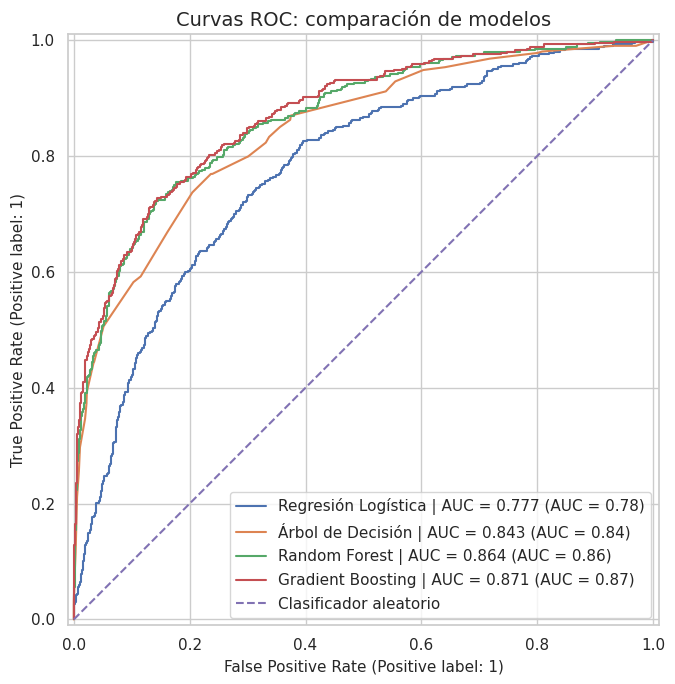

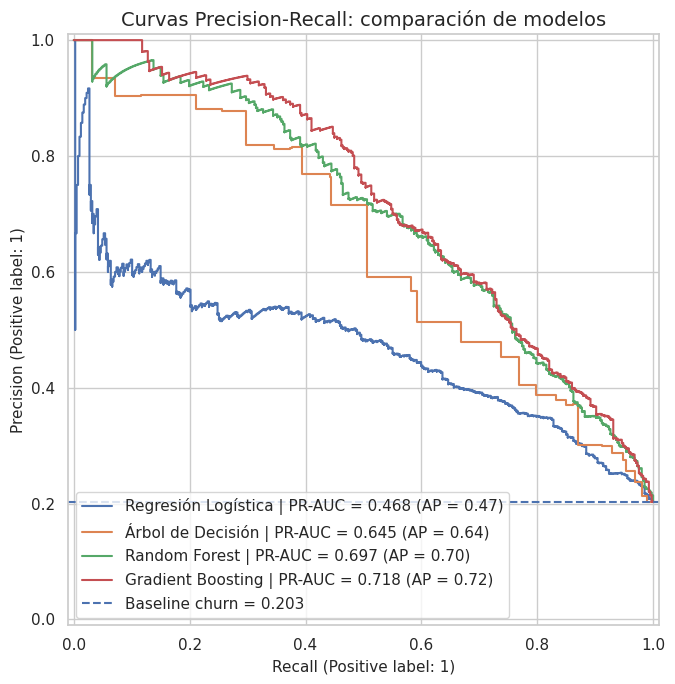

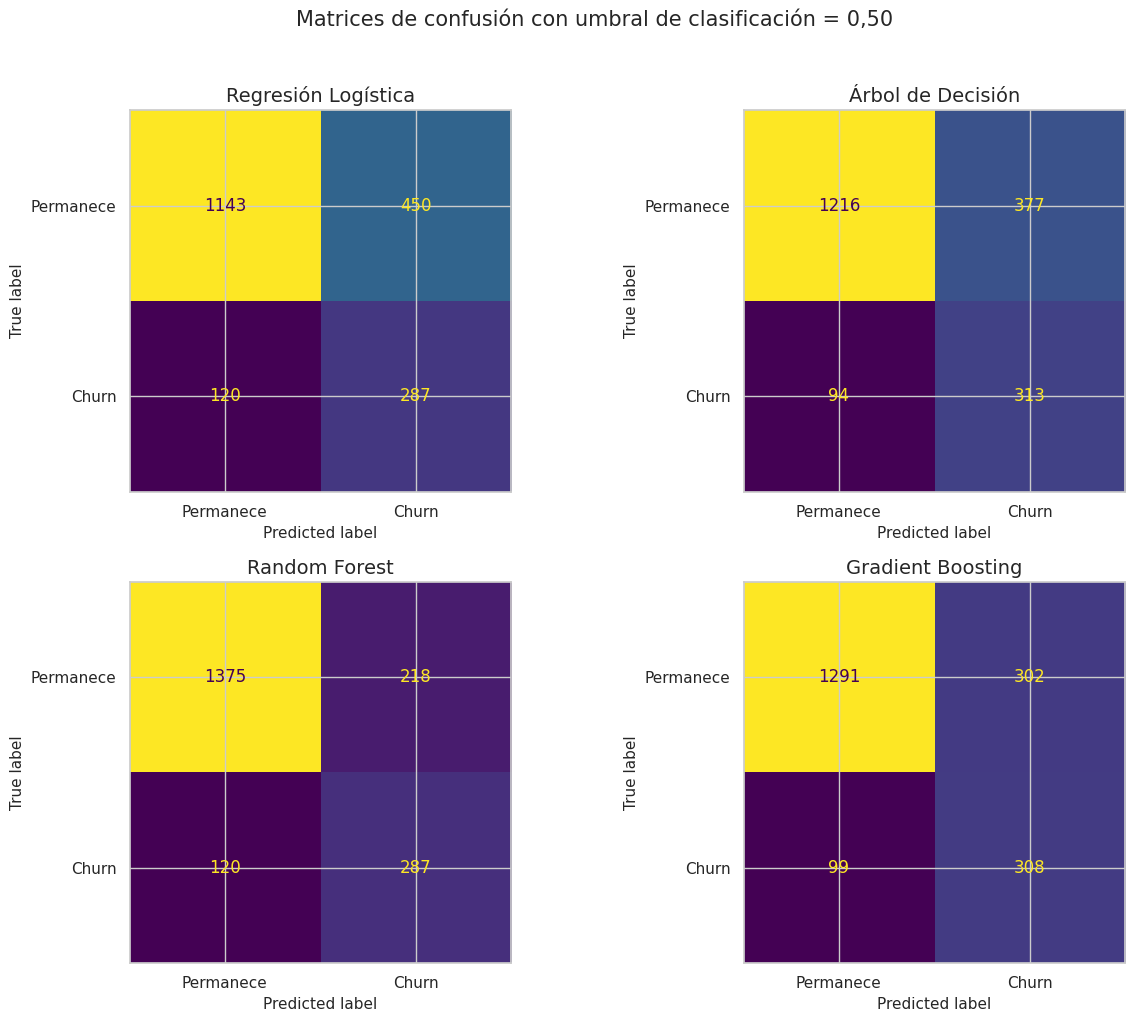


REPORTE DE CLASIFICACIÓN: Gradient Boosting
              precision    recall  f1-score   support

   Permanece     0.9288    0.8104    0.8656      1593
       Churn     0.5049    0.7568    0.6057       407

    accuracy                         0.7995      2000
   macro avg     0.7168    0.7836    0.7356      2000
weighted avg     0.8425    0.7995    0.8127      2000


REPORTE DE CLASIFICACIÓN: Random Forest
              precision    recall  f1-score   support

   Permanece     0.9197    0.8632    0.8905      1593
       Churn     0.5683    0.7052    0.6294       407

    accuracy                         0.8310      2000
   macro avg     0.7440    0.7842    0.7600      2000
weighted avg     0.8482    0.8310    0.8374      2000


REPORTE DE CLASIFICACIÓN: Árbol de Decisión
              precision    recall  f1-score   support

   Permanece     0.9282    0.7633    0.8378      1593
       Churn     0.4536    0.7690    0.5706       407

    accuracy                         0.7645      20


## Interpretación de resultados

El modelo con mayor capacidad de discriminación según **ROC-AUC** fue:

### Gradient Boosting

- **ROC-AUC:** 0.871
- **PR-AUC:** 0.718
- **Recall de churn:** 0.757
- **Precision de churn:** 0.505
- **F1-score:** 0.606
- **Balanced Accuracy:** 0.784

La métrica ROC-AUC mide la capacidad del modelo para ordenar correctamente a los clientes con churn por encima de los clientes que permanecen. 

El **recall** representa qué proporción de los clientes que realmente abandonan el banco fue detectada por el modelo. Esta métrica es especialmente importante porque un falso negativo representa un cliente que abandonará el banco sin recibir una intervención de retención.

La **precisión** muestra qué proporción de los clientes clasificados como riesgosos efectivamente abandonó el banco. Una precisión baja puede generar campañas de retención dirigidas a clientes que no tenían riesgo real.

Por tanto, ABC Bank no debe seleccionar el modelo solo por accuracy. La elección debe equilibrar ROC-AUC, recall, precisión, F1-score y el costo económico de perder clientes que no fueron detectados.


In [ ]:
# ============================================================
# 5. EVALUACIÓN Y COMPARACIÓN DE MODELOS
# Métricas obligatorias:
# - ROC-AUC
# - Precision
# - Recall
# - F1-score
# - Matriz de confusión
#
# Métricas adicionales modernas:
# - PR-AUC
# - Balanced Accuracy
# - Specificity
# - MCC
# - Brier Score
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    auc
)

# ------------------------------------------------------------
# Función de evaluación integral
# ------------------------------------------------------------
def evaluate_model(model_name, model, X_eval, y_eval, threshold=0.50):
    """
    Evalúa un clasificador binario usando probabilidades y un umbral.
    Retorna métricas, predicciones, probabilidades y matriz de confusión.
    """

    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    metrics = {
        "Modelo": model_name,
        "Threshold": threshold,
        "ROC_AUC": roc_auc_score(y_eval, y_proba),
        "PR_AUC": average_precision_score(y_eval, y_proba),
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1_Score": f1_score(y_eval, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_eval, y_pred),
        "Brier_Score": brier_score_loss(y_eval, y_proba),
        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    }

    return metrics, y_proba, y_pred, np.array([[tn, fp], [fn, tp]])

# ------------------------------------------------------------
# Evaluar todos los modelos con umbral estándar 0.50
# ------------------------------------------------------------
results = []
predictions_dict = {}
probabilities_dict = {}
confusion_matrices_dict = {}

for model_name, model in models.items():

    metrics, y_proba, y_pred, cm = evaluate_model(
        model_name=model_name,
        model=model,
        X_eval=X_test,
        y_eval=y_test,
        threshold=0.50
    )

    results.append(metrics)
    predictions_dict[model_name] = y_pred
    probabilities_dict[model_name] = y_proba
    confusion_matrices_dict[model_name] = cm

results_df = pd.DataFrame(results)

# Orden principal según ROC-AUC, luego PR-AUC y Recall.
results_df = results_df.sort_values(
    by=["ROC_AUC", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Modelo",
    "ROC_AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1_Score",
    "MCC",
    "Brier_Score"
]

print("=" * 100)
print("TABLA COMPARATIVA DE DESEMPEÑO")
print("=" * 100)

display(results_df[metric_columns].round(4))

# ------------------------------------------------------------
# Mejor modelo según ROC-AUC
# ------------------------------------------------------------
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

print(f"\nMejor modelo según ROC-AUC: {best_model_name}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC_AUC']:.4f}")
print(f"PR-AUC: {results_df.iloc[0]['PR_AUC']:.4f}")
print(f"Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"F1-score: {results_df.iloc[0]['F1_Score']:.4f}")

# ============================================================
# CURVAS ROC
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for model_name, y_proba in probabilities_dict.items():
    auc_value = roc_auc_score(y_test, y_proba)

    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=f"{model_name} | AUC = {auc_value:.3f}",
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
ax.set_title("Curvas ROC: comparación de modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# CURVAS PRECISION-RECALL
# Muy relevantes cuando existe desbalance de clases.
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for model_name, y_proba in probabilities_dict.items():

    pr_auc_value = average_precision_score(y_test, y_proba)

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_proba,
        name=f"{model_name} | PR-AUC = {pr_auc_value:.3f}",
        ax=ax
    )

baseline_churn = y_test.mean()
ax.axhline(
    baseline_churn,
    linestyle="--",
    label=f"Baseline churn = {baseline_churn:.3f}"
)

ax.set_title("Curvas Precision-Recall: comparación de modelos")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ============================================================
# MATRICES DE CONFUSIÓN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, models.keys()):

    cm = confusion_matrices_dict[model_name]

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Permanece", "Churn"]
    )

    display_cm.plot(
        ax=ax,
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model_name)

plt.suptitle(
    "Matrices de confusión con umbral de clasificación = 0,50",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# REPORTES DETALLADOS DE CLASIFICACIÓN
# ============================================================

for model_name in results_df["Modelo"]:

    print("\n" + "=" * 100)
    print(f"REPORTE DE CLASIFICACIÓN: {model_name}")
    print("=" * 100)

    print(
        classification_report(
            y_test,
            predictions_dict[model_name],
            target_names=["Permanece", "Churn"],
            digits=4,
            zero_division=0
        )
    )

# ============================================================
# INTERPRETACIÓN ECONÓMICA BÁSICA
# ============================================================

best_model_row = results_df.iloc[0]

display(Markdown(f"""
## Interpretación de resultados

El modelo con mayor capacidad de discriminación según **ROC-AUC** fue:

### {best_model_name}

- **ROC-AUC:** {best_model_row["ROC_AUC"]:.3f}
- **PR-AUC:** {best_model_row["PR_AUC"]:.3f}
- **Recall de churn:** {best_model_row["Recall"]:.3f}
- **Precision de churn:** {best_model_row["Precision"]:.3f}
- **F1-score:** {best_model_row["F1_Score"]:.3f}
- **Balanced Accuracy:** {best_model_row["Balanced_Accuracy"]:.3f}

La métrica ROC-AUC mide la capacidad del modelo para ordenar correctamente a los clientes con churn por encima de los clientes que permanecen.

El **recall** representa qué proporción de los clientes que realmente abandonan el banco fue detectada por el modelo. Esta métrica es especialmente importante porque un falso negativo representa un cliente que abandonará el banco sin recibir una intervención de retención.

La **precisión** muestra qué proporción de los clientes clasificados como riesgosos efectivamente abandonó el banco. Una precisión baja puede generar campañas de retención dirigidas a clientes que no tenían riesgo real.

Por tanto, ABC Bank no debe seleccionar el modelo solo por accuracy. La elección debe equilibrar ROC-AUC, recall, precisión, F1-score y el costo económico de perder clientes que no fueron detectados.
"""))

SELECCIÓN DE UMBRAL ÓPTIMO
Modelo analizado: Gradient Boosting
Costo supuesto por falso negativo: $100
Costo supuesto por falso positivo: $15
Umbral óptimo: 0.33
Costo mínimo estimado: $13,360
Recall asociado: 0.887
Precision asociada: 0.382
F1-score asociado: 0.534


,threshold,precision,recall,f1_score,false_positives,false_negatives,total_cost
28,0.330,0.382,0.887,0.534,584,46,13360
29,0.340,0.388,0.880,0.538,565,49,13375
33,0.380,0.416,0.850,0.559,485,61,13375
30,0.350,0.393,0.872,0.542,549,52,13435
32,0.370,0.408,0.855,0.553,504,59,13460
27,0.320,0.374,0.892,0.527,608,44,13520
37,0.420,0.445,0.821,0.577,416,73,13540
26,0.310,0.369,0.897,0.522,625,42,13575
31,0.360,0.400,0.860,0.546,526,57,13590
34,0.390,0.418,0.840,0.558,476,65,13640


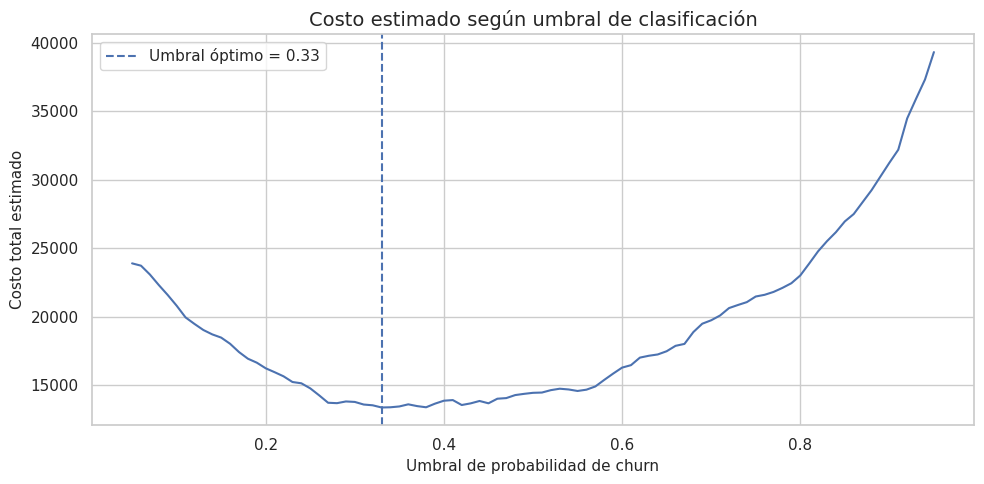


Métricas del mejor modelo con umbral económico óptimo:


,Modelo,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1_Score,MCC,Brier_Score
0,Gradient Boosting,0.871,0.718,0.685,0.760,0.382,0.887,0.633,0.534,0.420,0.140


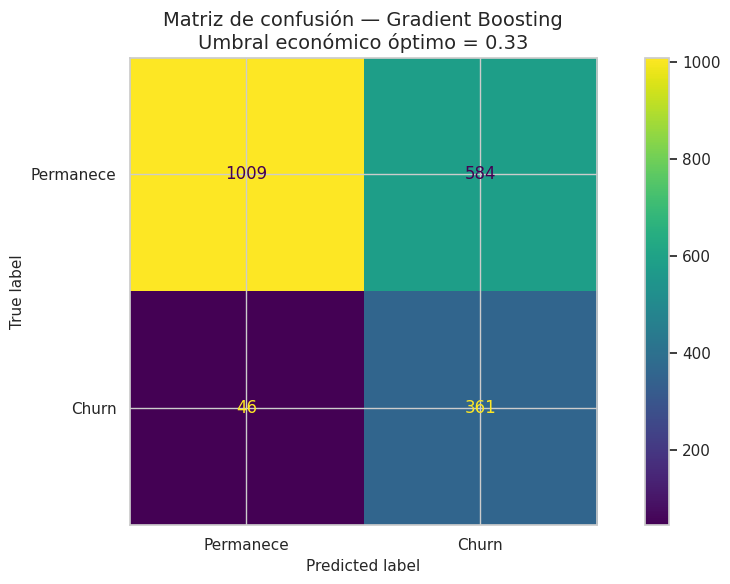


## Decisión de negocio basada en umbral

Con un costo supuesto de **$100** por no detectar a un cliente que abandonará el banco y de **$15** por contactar innecesariamente a un cliente, el umbral recomendado para **Gradient Boosting** es:

### 0.33

El umbral tradicional de 0,50 no siempre es el más conveniente. Si el costo de perder a un cliente es alto, puede ser racional reducir el umbral para identificar a más clientes riesgosos, aun cuando aumenten los falsos positivos.


In [ ]:
# ============================================================
# 5.1 SELECCIÓN DEL UMBRAL ÓPTIMO SEGÚN COSTO ECONÓMICO
# ============================================================

# Supuestos editables por ABC Bank:
# - Falso negativo: cliente que se va y no fue detectado.
# - Falso positivo: cliente marcado como riesgo, pero que no abandonaba.
#
# En general, perder un cliente suele ser más caro que contactarlo
# innecesariamente con una campaña de retención.
# ============================================================

COSTO_FALSO_NEGATIVO = 100
COSTO_FALSO_POSITIVO = 15

best_probabilities = probabilities_dict[best_model_name]

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []

for threshold in thresholds:

    predicted_class = (best_probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predicted_class
    ).ravel()

    total_cost = (
        fp * COSTO_FALSO_POSITIVO +
        fn * COSTO_FALSO_NEGATIVO
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predicted_class, zero_division=0),
        "recall": recall_score(y_test, predicted_class, zero_division=0),
        "f1_score": f1_score(y_test, predicted_class, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "total_cost": total_cost
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["total_cost"].idxmin()
]

optimal_threshold = best_threshold_row["threshold"]

print("=" * 90)
print("SELECCIÓN DE UMBRAL ÓPTIMO")
print("=" * 90)

print(f"Modelo analizado: {best_model_name}")
print(f"Costo supuesto por falso negativo: ${COSTO_FALSO_NEGATIVO:,.0f}")
print(f"Costo supuesto por falso positivo: ${COSTO_FALSO_POSITIVO:,.0f}")
print(f"Umbral óptimo: {optimal_threshold:.2f}")
print(f"Costo mínimo estimado: ${best_threshold_row['total_cost']:,.0f}")
print(f"Recall asociado: {best_threshold_row['recall']:.3f}")
print(f"Precision asociada: {best_threshold_row['precision']:.3f}")
print(f"F1-score asociado: {best_threshold_row['f1_score']:.3f}")

display(
    threshold_df.sort_values("total_cost")
    .head(10)
    .round(4)
)

plt.figure(figsize=(10, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["total_cost"]
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Umbral óptimo = {optimal_threshold:.2f}"
)

plt.title("Costo estimado según umbral de clasificación")
plt.xlabel("Umbral de probabilidad de churn")
plt.ylabel("Costo total estimado")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluación final del mejor modelo usando el umbral económico óptimo
metrics_optimal, y_proba_optimal, y_pred_optimal, cm_optimal = evaluate_model(
    model_name=best_model_name,
    model=best_model,
    X_eval=X_test,
    y_eval=y_test,
    threshold=optimal_threshold
)

print("\nMétricas del mejor modelo con umbral económico óptimo:")
display(
    pd.DataFrame([metrics_optimal])[metric_columns]
    .round(4)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_optimal,
    display_labels=["Permanece", "Churn"]
).plot(
    values_format="d"
)

plt.title(
    f"Matriz de confusión — {best_model_name}\n"
    f"Umbral económico óptimo = {optimal_threshold:.2f}"
)

plt.tight_layout()
plt.show()

display(Markdown(f"""
## Decisión de negocio basada en umbral

Con un costo supuesto de **${COSTO_FALSO_NEGATIVO:,.0f}** por no detectar a un cliente que abandonará el banco y de **${COSTO_FALSO_POSITIVO:,.0f}** por contactar innecesariamente a un cliente, el umbral recomendado para **{best_model_name}** es:

### {optimal_threshold:.2f}

El umbral tradicional de 0,50 no siempre es el más conveniente. Si el costo de perder a un cliente es alto, puede ser racional reducir el umbral para identificar a más clientes riesgosos, aun cuando aumenten los falsos positivos.
"""))

Variables más importantes según Random Forest:


,variable,importancia,modelo
1,age,0.334,Random Forest
4,products_number,0.220,Random Forest
3,balance,0.095,Random Forest
0,credit_score,0.070,Random Forest
5,estimated_salary,0.069,Random Forest
7,active_member,0.057,Random Forest
9,country_Germany,0.050,Random Forest
2,tenure,0.040,Random Forest
8,balance_zero,0.023,Random Forest
11,gender_Male,0.023,Random Forest



Variables más importantes según Gradient Boosting:


,variable,importancia,modelo
1,age,0.395,Gradient Boosting
4,products_number,0.263,Gradient Boosting
3,balance,0.101,Gradient Boosting
7,active_member,0.068,Gradient Boosting
9,country_Germany,0.059,Gradient Boosting
5,estimated_salary,0.040,Gradient Boosting
0,credit_score,0.031,Gradient Boosting
11,gender_Male,0.021,Gradient Boosting
2,tenure,0.009,Gradient Boosting
8,balance_zero,0.008,Gradient Boosting


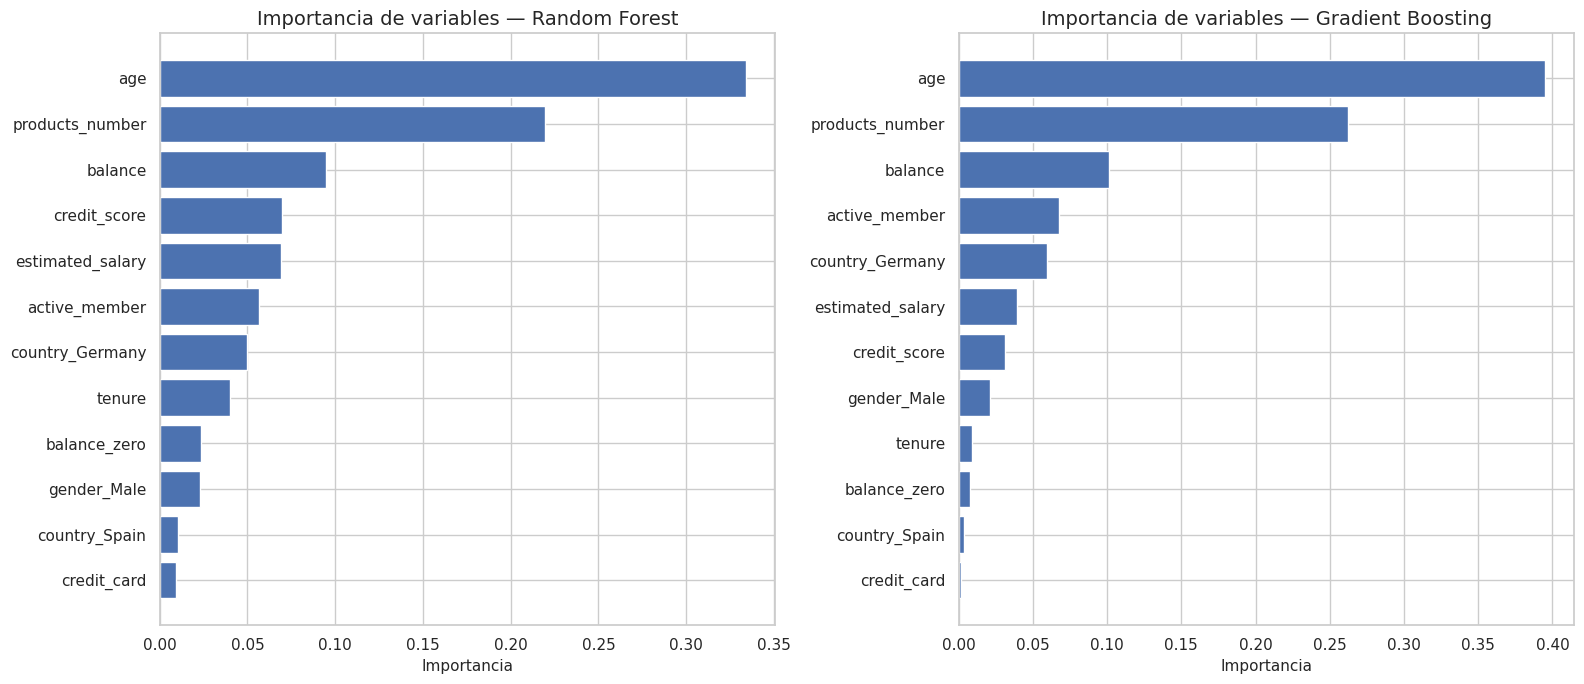


Variables estratégicas más relevantes en promedio:


,variable,importancia_rf,importancia_gb,importancia_promedio
1,age,0.334,0.395,0.364
10,products_number,0.220,0.263,0.241
2,balance,0.095,0.101,0.098
0,active_member,0.057,0.068,0.062
8,estimated_salary,0.069,0.040,0.054
4,country_Germany,0.050,0.059,0.054
7,credit_score,0.070,0.031,0.051
11,tenure,0.040,0.009,0.024
9,gender_Male,0.023,0.021,0.022
3,balance_zero,0.023,0.008,0.016


In [ ]:
# ============================================================
# 5.2 IMPORTANCIA DE VARIABLES
# Random Forest y Gradient Boosting
# ============================================================

def get_feature_importance(pipeline_model, model_name):
    """
    Extrae la importancia de variables de modelos basados en árboles.
    """

    fitted_preprocessor = pipeline_model.named_steps["preprocessor"]
    fitted_model = pipeline_model.named_steps["model"]

    transformed_features = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "variable": transformed_features,
        "importancia": fitted_model.feature_importances_
    }).sort_values("importancia", ascending=False)

    importance_df["modelo"] = model_name

    return importance_df

rf_importance = get_feature_importance(
    best_rf_model,
    "Random Forest"
)

gb_importance = get_feature_importance(
    best_gb_model,
    "Gradient Boosting"
)

print("Variables más importantes según Random Forest:")
display(rf_importance.head(15).round(4))

print("\nVariables más importantes según Gradient Boosting:")
display(gb_importance.head(15).round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_top = rf_importance.head(12).sort_values("importancia")
gb_top = gb_importance.head(12).sort_values("importancia")

axes[0].barh(
    rf_top["variable"],
    rf_top["importancia"]
)
axes[0].set_title("Importancia de variables — Random Forest")
axes[0].set_xlabel("Importancia")

axes[1].barh(
    gb_top["variable"],
    gb_top["importancia"]
)
axes[1].set_title("Importancia de variables — Gradient Boosting")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()

# Variables que aparecen como relevantes en ambos modelos
importance_combined = (
    rf_importance[["variable", "importancia"]]
    .rename(columns={"importancia": "importancia_rf"})
    .merge(
        gb_importance[["variable", "importancia"]]
        .rename(columns={"importancia": "importancia_gb"}),
        on="variable",
        how="outer"
    )
)

importance_combined["importancia_promedio"] = (
    importance_combined["importancia_rf"].fillna(0) +
    importance_combined["importancia_gb"].fillna(0)
) / 2

importance_combined = importance_combined.sort_values(
    "importancia_promedio",
    ascending=False
)

print("\nVariables estratégicas más relevantes en promedio:")
display(importance_combined.head(15).round(4))

La evaluación comparativa muestra que Gradient Boosting logró el mejor desempeño predictivo global, alcanzando un ROC-AUC de 0,871 y un PR-AUC de 0,718. Esto indica que posee la mayor capacidad para ordenar correctamente a los clientes según su riesgo de abandono. A un umbral de 0,50, el modelo identificó al 75,7% de los churners reales, aunque con una precisión de 50,5%.

Random Forest presentó un rendimiento muy cercano en ROC-AUC, con 0,865, pero obtuvo mejores resultados en precisión, F1-score, MCC y Brier Score. Por ello, Gradient Boosting es recomendable para maximizar la detección de clientes en riesgo, mientras que Random Forest es una alternativa adecuada cuando el presupuesto de retención es limitado y se requiere contactar a clientes con mayor certeza.

El análisis de umbral mostró que, bajo un escenario económico donde no detectar un cliente churner cuesta más que contactarlo innecesariamente, el umbral óptimo se reduce desde 0,50 a 0,33. Con este ajuste, Gradient Boosting aumenta el recall desde 75,7% a 88,7%, detectando 361 de los 407 churners reales. Sin embargo, esta decisión implica contactar a 945 de los 2.000 clientes evaluados, por lo que su aplicación depende de la capacidad operativa y del presupuesto de la campaña.

Las variables más relevantes para explicar churn fueron edad, número de productos, saldo, actividad del cliente y país de residencia. Estas variables deben utilizarse para diseñar campañas de retención segmentadas, especialmente para clientes inactivos, clientes con alto saldo y riesgo elevado, y segmentos geográficos con mayor tasa de abandono.



### 6. Umbral Óptimo y Balance entre Métricas de Negocio

Una vez seleccionado el mejor modelo:

- Determine el **umbral de decisión óptimo** (no necesariamente 0,5).
- Compare el desempeño del modelo bajo distintos umbrales.
- Responda y argumente la siguiente pregunta en términos de negocio:

> **¿Es más importante para ABC Bank maximizar el Recall o la Precisión?**
>
> - **Recall alto** → capturar la mayor cantidad posible de clientes que abandonarán (minimizar clientes perdidos).
> - **Precisión alta** → evitar falsas alarmas y no desperdiciar el presupuesto de retención.



SELECCIÓN DEL UMBRAL ÓPTIMO
Modelo seleccionado: Gradient Boosting
Costo por contacto de retención: $15
Costo por cliente perdido no detectado: $150

Umbral que minimiza el costo económico:
Umbral óptimo por costo: 0.31
Costo total mínimo estimado: $20,805
Recall: 0.902
Precision: 0.372
F1-score: 0.527

Umbral que maximiza F1-score:
Umbral F1 óptimo: 0.63
F1-score máximo: 0.637

Umbral que maximiza el índice de Youden:
Umbral Youden óptimo: 0.47
Youden J máximo: 0.572

Comparación de umbrales relevantes:


,umbral,precision,recall,f1_score,specificity,clientes_contactados,falsos_negativos,costo_campana,costo_churn_no_detectado,costo_total_estimado
25,0.300,0.363,0.904,0.518,0.595,1013,39,15195,5850,21045
26,0.310,0.372,0.902,0.526,0.611,987,40,14805,6000,20805
35,0.400,0.438,0.826,0.572,0.729,767,71,11505,10650,22155
42,0.470,0.492,0.776,0.603,0.795,642,91,9630,13650,23280
45,0.500,0.514,0.735,0.605,0.822,582,108,8730,16200,24930
58,0.630,0.650,0.624,0.637,0.914,391,153,5865,22950,28815


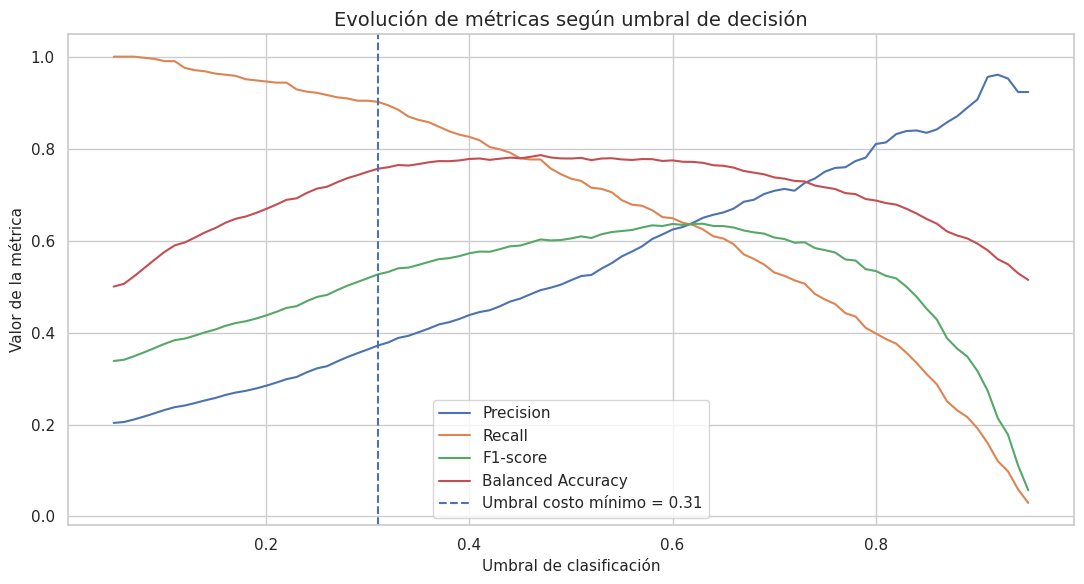

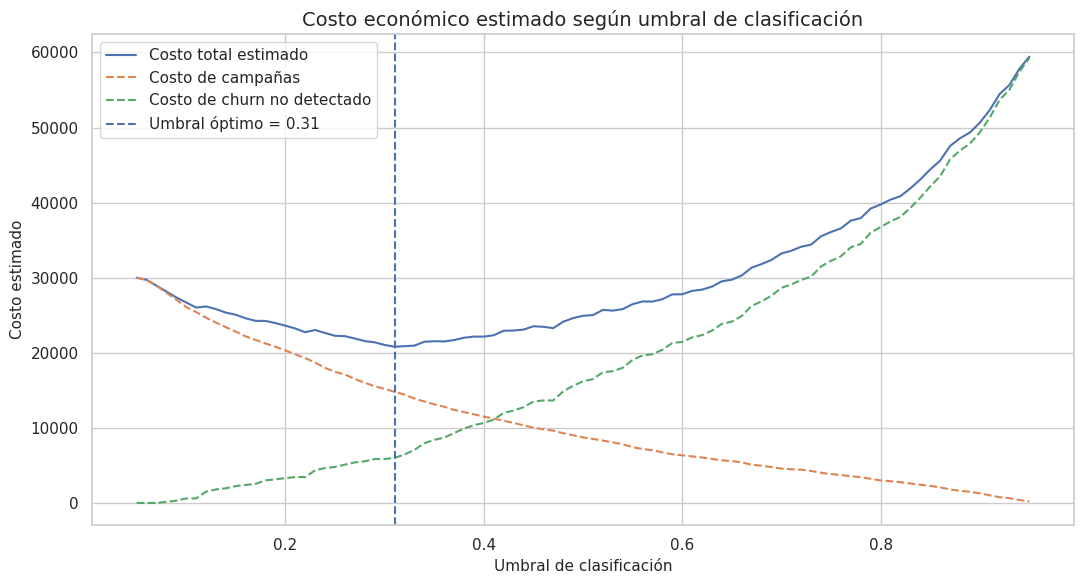


Resultados finales en conjunto de prueba:


,modelo,umbral_optimo,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1_score,brier_score,clientes_contactados,falsos_positivos,falsos_negativos,costo_campana,costo_churn_no_detectado,costo_total_estimado
0,Gradient Boosting,0.310,0.871,0.718,0.666,0.752,0.369,0.897,0.608,0.522,0.140,990,625,42,14850,6300,21150


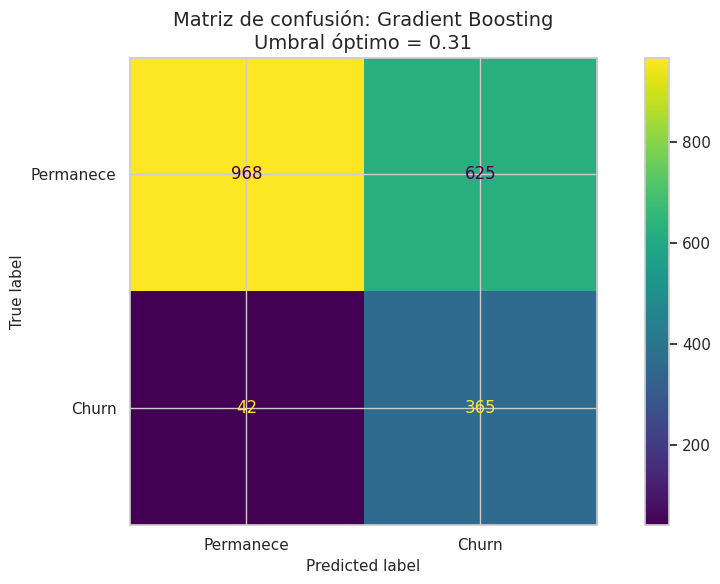

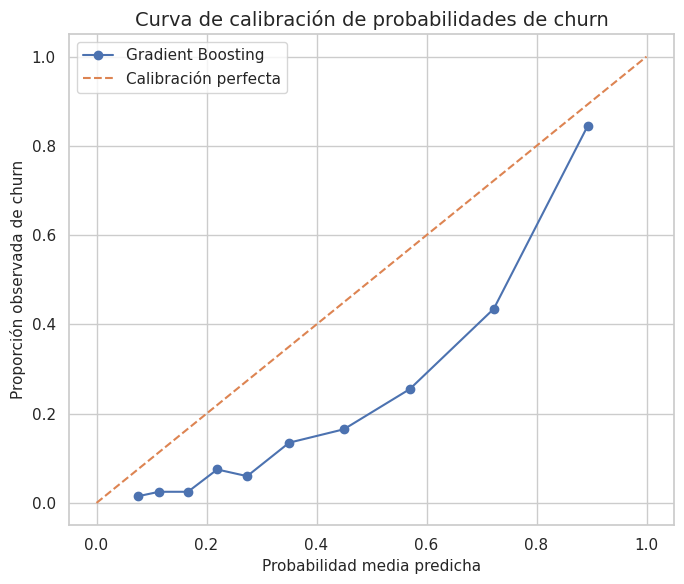


# Interpretación del umbral óptimo

El modelo seleccionado fue **Gradient Boosting**. El umbral tradicional de 0,50 no necesariamente es el más conveniente desde una perspectiva económica.

Bajo el supuesto de que contactar a un cliente cuesta **$15** y perder a un cliente no detectado cuesta aproximadamente **$150**, el umbral que minimiza el costo estimado es:

## 0.31

Con este umbral, el modelo prioriza un equilibrio entre:

- identificar clientes que realmente abandonarán;
- evitar perder demasiados clientes por no haberlos detectado;
- controlar el presupuesto destinado a campañas de retención;
- no contactar masivamente a clientes con bajo riesgo.

## ¿Es más importante maximizar Recall o Precision?

Para ABC Bank, en general, debe priorizarse un **Recall relativamente alto**, porque un falso negativo representa un cliente que abandonará el banco sin recibir una intervención de retención.

Sin embargo, no conviene maximizar Recall de manera extrema, porque eso puede producir demasiados falsos positivos y elevar el costo de campañas sobre clientes que probablemente no abandonarían.

Por ello, la decisión recomendada es usar el umbral elegido por costo económico y revisar periódicamente los supuestos de valor del cliente, presupuesto de retención y capacidad operativa de la campaña.


In [ ]:
# ============================================================
# 6. UMBRAL ÓPTIMO Y BALANCE ENTRE MÉTRICAS DE NEGOCIO
# ============================================================
# Este bloque usa una división de validación dentro del conjunto
# de entrenamiento para elegir el umbral.
#
# Luego, el modelo se reentrena con todo X_train y se evalúa una
# sola vez sobre X_test. Esto evita elegir el umbral directamente
# con el conjunto de prueba y hace el análisis más riguroso.
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from IPython.display import display, Markdown

# ------------------------------------------------------------
# 1. Configuración de supuestos económicos
# ------------------------------------------------------------
# Ajusta estos valores si el profesor o ABC Bank entrega datos
# reales sobre el costo de campañas y el valor perdido por churn.

COSTO_CONTACTO_RETENCION = 15
COSTO_CLIENTE_PERDIDO = 150

# Interpretación:
# - COSTO_CONTACTO_RETENCION:
#   costo de contactar a un cliente mediante llamada, email,
#   campaña, ejecutivo o beneficio de retención.
#
# - COSTO_CLIENTE_PERDIDO:
#   pérdida económica estimada si el cliente abandona y no se
#   detecta a tiempo. Puede incluir margen perdido, menor uso
#   de productos, costo de captación de reemplazo, etc.

RANDOM_STATE = 42

# ------------------------------------------------------------
# 2. División interna para seleccionar el umbral
# ------------------------------------------------------------

X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE
)

def fit_model_with_weights(model, X_data, y_data, model_name):
    """
    Ajusta el modelo seleccionado.
    Gradient Boosting requiere sample_weight porque no permite
    class_weight directamente.
    """

    fitted_model = clone(model)

    if model_name == "Gradient Boosting":
        sample_weights = np.where(
            y_data.to_numpy() == 1,
            class_weights[1],
            class_weights[0]
        )

        fitted_model.fit(
            X_data,
            y_data,
            model__sample_weight=sample_weights
        )
    else:
        fitted_model.fit(X_data, y_data)

    return fitted_model

# Modelo provisional para seleccionar el umbral
threshold_model = fit_model_with_weights(
    model=best_model,
    X_data=X_fit,
    y_data=y_fit,
    model_name=best_model_name
)

validation_probabilities = threshold_model.predict_proba(
    X_validation
)[:, 1]

# ------------------------------------------------------------
# 3. Evaluar múltiples umbrales
# ------------------------------------------------------------

thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred_validation = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred_validation,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_validation,
        y_pred_validation,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        y_pred_validation,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        y_pred_validation,
        zero_division=0
    )

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Índice de Youden:
    # Busca equilibrio entre recall y especificidad.
    youden_j = recall + specificity - 1

    # Costo de todas las intervenciones realizadas:
    costo_campana = (tp + fp) * COSTO_CONTACTO_RETENCION

    # Costo de clientes que abandonan sin ser detectados:
    costo_churn_no_detectado = fn * COSTO_CLIENTE_PERDIDO

    costo_total = costo_campana + costo_churn_no_detectado

    threshold_results.append({
        "umbral": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "specificity": specificity,
        "balanced_accuracy": balanced_accuracy_score(
            y_validation,
            y_pred_validation
        ),
        "youden_j": youden_j,
        "clientes_contactados": tp + fp,
        "verdaderos_positivos": tp,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "costo_campana": costo_campana,
        "costo_churn_no_detectado": costo_churn_no_detectado,
        "costo_total_estimado": costo_total
    })

threshold_df = pd.DataFrame(threshold_results)

# Umbral que minimiza el costo total del escenario de negocio
best_cost_row = threshold_df.loc[
    threshold_df["costo_total_estimado"].idxmin()
]

threshold_cost_optimal = best_cost_row["umbral"]

# Umbral que maximiza F1-score
best_f1_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

threshold_f1_optimal = best_f1_row["umbral"]

# Umbral que maximiza equilibrio entre recall y especificidad
best_youden_row = threshold_df.loc[
    threshold_df["youden_j"].idxmax()
]

threshold_youden_optimal = best_youden_row["umbral"]

print("=" * 95)
print("SELECCIÓN DEL UMBRAL ÓPTIMO")
print("=" * 95)

print(f"Modelo seleccionado: {best_model_name}")
print(f"Costo por contacto de retención: ${COSTO_CONTACTO_RETENCION:,.0f}")
print(f"Costo por cliente perdido no detectado: ${COSTO_CLIENTE_PERDIDO:,.0f}")

print("\nUmbral que minimiza el costo económico:")
print(f"Umbral óptimo por costo: {threshold_cost_optimal:.2f}")
print(f"Costo total mínimo estimado: ${best_cost_row['costo_total_estimado']:,.0f}")
print(f"Recall: {best_cost_row['recall']:.3f}")
print(f"Precision: {best_cost_row['precision']:.3f}")
print(f"F1-score: {best_cost_row['f1_score']:.3f}")

print("\nUmbral que maximiza F1-score:")
print(f"Umbral F1 óptimo: {threshold_f1_optimal:.2f}")
print(f"F1-score máximo: {best_f1_row['f1_score']:.3f}")

print("\nUmbral que maximiza el índice de Youden:")
print(f"Umbral Youden óptimo: {threshold_youden_optimal:.2f}")
print(f"Youden J máximo: {best_youden_row['youden_j']:.3f}")

# ------------------------------------------------------------
# 4. Comparar umbrales relevantes
# ------------------------------------------------------------

thresholds_to_compare = sorted(set([
    0.30,
    0.40,
    0.50,
    round(threshold_cost_optimal, 2),
    round(threshold_f1_optimal, 2),
    round(threshold_youden_optimal, 2)
]))

comparison_thresholds = threshold_df[
    threshold_df["umbral"].round(2).isin(thresholds_to_compare)
].copy()

comparison_thresholds = comparison_thresholds.sort_values("umbral")

print("\nComparación de umbrales relevantes:")
display(
    comparison_thresholds[
        [
            "umbral",
            "precision",
            "recall",
            "f1_score",
            "specificity",
            "clientes_contactados",
            "falsos_negativos",
            "costo_campana",
            "costo_churn_no_detectado",
            "costo_total_estimado"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# 5. Gráfico: métricas según umbral
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(threshold_df["umbral"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["umbral"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["umbral"], threshold_df["f1_score"], label="F1-score")
plt.plot(
    threshold_df["umbral"],
    threshold_df["balanced_accuracy"],
    label="Balanced Accuracy"
)

plt.axvline(
    threshold_cost_optimal,
    linestyle="--",
    label=f"Umbral costo mínimo = {threshold_cost_optimal:.2f}"
)

plt.title("Evolución de métricas según umbral de decisión")
plt.xlabel("Umbral de clasificación")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Gráfico: costo económico según umbral
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    threshold_df["umbral"],
    threshold_df["costo_total_estimado"],
    label="Costo total estimado"
)

plt.plot(
    threshold_df["umbral"],
    threshold_df["costo_campana"],
    linestyle="--",
    label="Costo de campañas"
)

plt.plot(
    threshold_df["umbral"],
    threshold_df["costo_churn_no_detectado"],
    linestyle="--",
    label="Costo de churn no detectado"
)

plt.axvline(
    threshold_cost_optimal,
    linestyle="--",
    label=f"Umbral óptimo = {threshold_cost_optimal:.2f}"
)

plt.title("Costo económico estimado según umbral de clasificación")
plt.xlabel("Umbral de clasificación")
plt.ylabel("Costo estimado")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Entrenar modelo final usando todos los datos de entrenamiento
# ------------------------------------------------------------

final_model_deployed = fit_model_with_weights(
    model=best_model,
    X_data=X_train,
    y_data=y_train,
    model_name=best_model_name
)

test_probabilities_final = final_model_deployed.predict_proba(
    X_test
)[:, 1]

test_predictions_final = (
    test_probabilities_final >= threshold_cost_optimal
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions_final,
    labels=[0, 1]
).ravel()

test_precision = precision_score(
    y_test,
    test_predictions_final,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions_final,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions_final,
    zero_division=0
)

test_specificity = tn / (tn + fp)

test_campaign_cost = (tp + fp) * COSTO_CONTACTO_RETENCION
test_missed_churn_cost = fn * COSTO_CLIENTE_PERDIDO
test_total_cost = test_campaign_cost + test_missed_churn_cost

final_threshold_metrics = pd.DataFrame([{
    "modelo": best_model_name,
    "umbral_optimo": threshold_cost_optimal,
    "roc_auc": roc_auc_score(y_test, test_probabilities_final),
    "pr_auc": average_precision_score(y_test, test_probabilities_final),
    "accuracy": accuracy_score(y_test, test_predictions_final),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_predictions_final
    ),
    "precision": test_precision,
    "recall": test_recall,
    "specificity": test_specificity,
    "f1_score": test_f1,
    "brier_score": brier_score_loss(
        y_test,
        test_probabilities_final
    ),
    "clientes_contactados": tp + fp,
    "falsos_positivos": fp,
    "falsos_negativos": fn,
    "costo_campana": test_campaign_cost,
    "costo_churn_no_detectado": test_missed_churn_cost,
    "costo_total_estimado": test_total_cost
}])

print("\nResultados finales en conjunto de prueba:")
display(final_threshold_metrics.round(4))

# ------------------------------------------------------------
# 8. Matriz de confusión con umbral óptimo
# ------------------------------------------------------------

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test,
        test_predictions_final,
        labels=[0, 1]
    ),
    display_labels=["Permanece", "Churn"]
).plot(values_format="d")

plt.title(
    f"Matriz de confusión: {best_model_name}\n"
    f"Umbral óptimo = {threshold_cost_optimal:.2f}"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Curva de calibración
# ------------------------------------------------------------
# Permite evaluar si una probabilidad estimada de, por ejemplo,
# 0,70 representa aproximadamente 70% de churn observado.

observed_frequency, predicted_probability = calibration_curve(
    y_test,
    test_probabilities_final,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    predicted_probability,
    observed_frequency,
    marker="o",
    label=best_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

plt.title("Curva de calibración de probabilidades de churn")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Proporción observada de churn")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Interpretación de negocio
# ------------------------------------------------------------

display(Markdown(f"""
# Interpretación del umbral óptimo

El modelo seleccionado fue **{best_model_name}**. El umbral tradicional de 0,50 no necesariamente es el más conveniente desde una perspectiva económica.

Bajo el supuesto de que contactar a un cliente cuesta **${COSTO_CONTACTO_RETENCION:,.0f}** y perder a un cliente no detectado cuesta aproximadamente **${COSTO_CLIENTE_PERDIDO:,.0f}**, el umbral que minimiza el costo estimado es:

## {threshold_cost_optimal:.2f}

Con este umbral, el modelo prioriza un equilibrio entre:

- identificar clientes que realmente abandonarán;
- evitar perder demasiados clientes por no haberlos detectado;
- controlar el presupuesto destinado a campañas de retención;
- no contactar masivamente a clientes con bajo riesgo.

## ¿Es más importante maximizar Recall o Precision?

Para ABC Bank, en general, debe priorizarse un **Recall relativamente alto**, porque un falso negativo representa un cliente que abandonará el banco sin recibir una intervención de retención.

Sin embargo, no conviene maximizar Recall de manera extrema, porque eso puede producir demasiados falsos positivos y elevar el costo de campañas sobre clientes que probablemente no abandonarían.

Por ello, la decisión recomendada es usar el umbral elegido por costo económico y revisar periódicamente los supuestos de valor del cliente, presupuesto de retención y capacidad operativa de la campaña.
"""))

El análisis de umbral se realizó utilizando una partición de validación interna dentro del conjunto de entrenamiento, mientras que el conjunto de prueba se reservó para la evaluación final. Esta metodología permitió seleccionar un umbral de clasificación sin utilizar el conjunto de prueba durante la decisión, reduciendo el riesgo de sobreajuste.

Bajo un escenario económico ilustrativo, donde contactar a un cliente cuesta USD 15 y perder a un cliente churner no detectado cuesta USD 150, el umbral que minimiza el costo total estimado es 0,31. En el conjunto de prueba, este umbral permitió alcanzar un recall de 89,7%, detectando 365 de los 407 clientes que realmente abandonaron el banco.

La adopción de este umbral implica una reducción de falsos negativos, pero también un aumento de falsos positivos y del número de clientes contactados. En particular, se contactaron 990 de los 2.000 clientes evaluados, de los cuales 365 correspondían a churners reales. Por lo tanto, se concluye que para ABC Bank conviene priorizar un recall alto, dado que el costo de perder un cliente es superior al costo de realizar una intervención preventiva.

Sin embargo, el recall no debe maximizarse de manera ilimitada. La política recomendada es utilizar el umbral de 0,31 mientras los supuestos de costo, presupuesto de campaña y capacidad operativa se mantengan vigentes. Estos parámetros deben revisarse periódicamente con datos reales sobre valor de vida del cliente, efectividad de las campañas y costo comercial de retención.



### 7. Análisis de Negocio y Recomendaciones

Una vez que el modelo identifique las características más relevantes:

- Discuta qué factores influyen más fuertemente en el *churn* (p.ej., bajo puntaje crediticio, saldo alto pero cliente inactivo).
- Proponga **acciones concretas** para cada factor clave.
  - *Ejemplo:* Ofrecer incentivos personalizados a clientes inactivos de alto valor.
  - *Ejemplo:* Revisar precios o beneficios para clientes con alta probabilidad de *churn* en ciertos países.

Considere también:
- ¿Qué podría hacer el banco el próximo trimestre para **reducir el *churn* en un 10%**?
- ¿Cómo podría este modelo **integrarse en una campaña de retención de clientes**?



In [ ]:
# ============================================================
# CORRECCIÓN: CREACIÓN ROBUSTA DE GRUPOS DE SALDO
# ============================================================
# El problema ocurre porque existen muchos clientes con balance = 0.
# Primero se separan esos clientes y luego se crean cuantiles solo
# para quienes sí poseen saldo positivo.
# ============================================================

# ------------------------------------------------------------
# 1. Crear grupo etario de forma segura
# ------------------------------------------------------------

scored_clients["grupo_edad"] = pd.cut(
    scored_clients["age"],
    bins=[0, 30, 40, 50, 60, 120],
    labels=["<=30", "31-40", "41-50", "51-60", ">60"],
    include_lowest=True
)

# ------------------------------------------------------------
# 2. Crear grupo de saldo sin errores por valores repetidos
# ------------------------------------------------------------

# Inicialmente todos los clientes con saldo 0 quedan identificados
# como un grupo especial, porque tienen un perfil distinto.
scored_clients["grupo_saldo"] = "Saldo cero"

# Máscara para clientes con saldo positivo
mask_saldo_positivo = scored_clients["balance"] > 0

# Serie solo con clientes que tienen saldo positivo
saldo_positivo = scored_clients.loc[
    mask_saldo_positivo,
    "balance"
].copy()

# Crear cuantiles sin etiquetas fijas.
# labels=False evita el error si Pandas crea menos de cuatro grupos.
codigo_cuartil = pd.qcut(
    saldo_positivo,
    q=4,
    labels=False,
    duplicates="drop"
)

# Número real de grupos que logró formar Pandas
n_grupos_reales = int(codigo_cuartil.max()) + 1

# Etiquetas disponibles según el número real de grupos
etiquetas_saldo = [
    "Saldo bajo",
    "Saldo medio-bajo",
    "Saldo medio-alto",
    "Saldo alto"
][:n_grupos_reales]

# Relación entre código numérico y nombre del grupo
mapa_saldo = {
    i: etiqueta
    for i, etiqueta in enumerate(etiquetas_saldo)
}

# Asignar etiquetas a los clientes con saldo positivo
scored_clients.loc[
    mask_saldo_positivo,
    "grupo_saldo"
] = codigo_cuartil.map(mapa_saldo).astype("object")

# Orden lógico para mostrar resultados
orden_saldo = [
    "Saldo cero",
    "Saldo bajo",
    "Saldo medio-bajo",
    "Saldo medio-alto",
    "Saldo alto"
]

scored_clients["grupo_saldo"] = pd.Categorical(
    scored_clients["grupo_saldo"],
    categories=orden_saldo,
    ordered=True
)

print("Distribución de clientes por grupo de saldo:")
display(
    scored_clients["grupo_saldo"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("grupo_saldo")
    .reset_index(name="clientes")
)

Distribución de clientes por grupo de saldo:


,grupo_saldo,clientes
0,Saldo cero,726
1,Saldo bajo,319
2,Saldo medio-bajo,318
3,Saldo medio-alto,318
4,Saldo alto,319


In [ ]:
# Recrear la variable derivada dentro de scored_clients
# 1 = cliente con saldo igual a cero
# 0 = cliente con saldo positivo
scored_clients["balance_zero"] = (
    scored_clients["balance"].fillna(0).eq(0)
).astype(int)

In [ ]:
# ============================================================
# 3. PERFIL DE RIESGO POR SEGMENTOS
# ============================================================

# ------------------------------------------------------------
# Corrección: asegurar que las variables derivadas existan
# dentro de la tabla scored_clients.
# ------------------------------------------------------------

scored_clients = scored_clients.copy()

# Indicador de saldo cero.
# Se crea nuevamente porque puede no haberse incluido al armar
# la tabla utilizada para el análisis comercial.
if "balance_zero" not in scored_clients.columns:
    scored_clients["balance_zero"] = (
        scored_clients["balance"].fillna(0).eq(0)
    ).astype(int)

# Grupo etario, por si la tabla no lo contiene.
if "grupo_edad" not in scored_clients.columns:
    scored_clients["grupo_edad"] = pd.cut(
        scored_clients["age"],
        bins=[0, 30, 40, 50, 60, 120],
        labels=["<=30", "31-40", "41-50", "51-60", ">60"],
        include_lowest=True
    )

# Verificación de grupo de saldo.
if "grupo_saldo" not in scored_clients.columns:
    raise ValueError(
        "No existe la columna 'grupo_saldo'. "
        "Ejecuta primero la celda de creación de grupos de saldo."
    )

# ------------------------------------------------------------
# Variables que se analizarán por segmento
# ------------------------------------------------------------

segment_variables_solicitadas = [
    "country",
    "gender",
    "active_member",
    "credit_card",
    "products_number",
    "balance_zero",
    "grupo_edad",
    "grupo_saldo"
]

# Evita que el notebook se detenga si una variable no existe.
segment_variables = [
    variable
    for variable in segment_variables_solicitadas
    if variable in scored_clients.columns
]

variables_faltantes = [
    variable
    for variable in segment_variables_solicitadas
    if variable not in scored_clients.columns
]

if variables_faltantes:
    print("Variables no disponibles y omitidas:", variables_faltantes)

# Etiquetas más claras para la presentación final.
etiquetas_segmentos = {
    "active_member": {
        0: "Inactivo",
        1: "Activo"
    },
    "credit_card": {
        0: "Sin tarjeta",
        1: "Con tarjeta"
    },
    "balance_zero": {
        0: "Saldo positivo",
        1: "Saldo cero"
    }
}

segment_results = {}

for variable in segment_variables:

    tabla_segmento = (
        scored_clients
        .groupby(variable, observed=False, dropna=False)
        .agg(
            clientes=("probabilidad_churn", "size"),
            probabilidad_media=("probabilidad_churn", "mean"),
            churn_observado=("churn_real", "mean"),
            clientes_alto_riesgo=(
                "nivel_riesgo",
                lambda x: (x == "Alto").sum()
            )
        )
        .reset_index()
    )

    tabla_segmento["porcentaje_alto_riesgo"] = (
        tabla_segmento["clientes_alto_riesgo"]
        / tabla_segmento["clientes"]
        * 100
    ).round(2)

    tabla_segmento["probabilidad_media"] = (
        tabla_segmento["probabilidad_media"] * 100
    ).round(2)

    tabla_segmento["churn_observado"] = (
        tabla_segmento["churn_observado"] * 100
    ).round(2)

    tabla_segmento = tabla_segmento.sort_values(
        by="probabilidad_media",
        ascending=False
    ).reset_index(drop=True)

    segment_results[variable] = tabla_segmento.copy()

    tabla_mostrar = tabla_segmento.copy()

    # Cambiar 0 y 1 por etiquetas comprensibles.
    if variable in etiquetas_segmentos:
        tabla_mostrar[variable] = (
            tabla_mostrar[variable]
            .map(etiquetas_segmentos[variable])
            .fillna(tabla_mostrar[variable].astype(str))
        )

    print(f"\nPerfil de riesgo según: {variable}")
    display(tabla_mostrar)


Perfil de riesgo según: country


,country,clientes,probabilidad_media,churn_observado,clientes_alto_riesgo,porcentaje_alto_riesgo
0,Germany,504,52.390,29.960,368,73.020
1,Spain,475,34.320,17.050,209,44.000
2,France,1021,33.270,17.140,413,40.450



Perfil de riesgo según: gender


,gender,clientes,probabilidad_media,churn_observado,clientes_alto_riesgo,porcentaje_alto_riesgo
0,Female,930,43.180,25.050,534,57.420
1,Male,1070,34.130,16.260,456,42.620



Perfil de riesgo según: active_member


...

,balance_zero,clientes,probabilidad_media,churn_observado,clientes_alto_riesgo,porcentaje_alto_riesgo
0,Saldo positivo,1274,44.760,23.550,770,60.440
1,Saldo cero,726,27.080,14.740,220,30.300



Perfil de riesgo según: grupo_edad


,grupo_edad,clientes,probabilidad_media,churn_observado,clientes_alto_riesgo,porcentaje_alto_riesgo
0,51-60,152,69.480,58.550,136,89.470
1,41-50,492,57.720,34.960,403,81.910
2,>60,89,42.550,24.720,48,53.930
3,31-40,868,29.450,11.410,334,38.480
4,<=30,399,20.960,6.270,69,17.290



Perfil de riesgo según: grupo_saldo


,grupo_saldo,clientes,probabilidad_media,churn_observado,clientes_alto_riesgo,porcentaje_alto_riesgo
0,Saldo medio-bajo,318,46.450,27.360,200,62.890
1,Saldo medio-alto,318,46.010,24.840,201,63.210
2,Saldo alto,319,43.700,23.200,183,57.370
3,Saldo bajo,319,42.870,18.810,186,58.310
4,Saldo cero,726,27.080,14.740,220,30.300


In [ ]:
# ============================================================
# 4. ANÁLISIS ESPECÍFICO POR GRUPO DE SALDO
# ============================================================

analisis_saldo = (
    scored_clients
    .groupby("grupo_saldo", observed=False)
    .agg(
        clientes=("customer_id", "count"),
        probabilidad_media_churn=("probabilidad_churn", "mean"),
        churn_observado=("churn_real", "mean"),
        clientes_alto_riesgo=(
            "nivel_riesgo",
            lambda x: (x == "Alto").sum()
        )
    )
    .reset_index()
)

analisis_saldo["probabilidad_media_churn"] = (
    analisis_saldo["probabilidad_media_churn"] * 100
).round(2)

analisis_saldo["churn_observado"] = (
    analisis_saldo["churn_observado"] * 100
).round(2)

print("Análisis de riesgo por grupo de saldo:")
display(analisis_saldo)

Análisis de riesgo por grupo de saldo:


,grupo_saldo,clientes,probabilidad_media_churn,churn_observado,clientes_alto_riesgo
0,Saldo cero,726,27.080,14.740,220
1,Saldo bajo,319,42.870,18.810,186
2,Saldo medio-bajo,318,46.450,27.360,200
3,Saldo medio-alto,318,46.010,24.840,201
4,Saldo alto,319,43.700,23.200,183


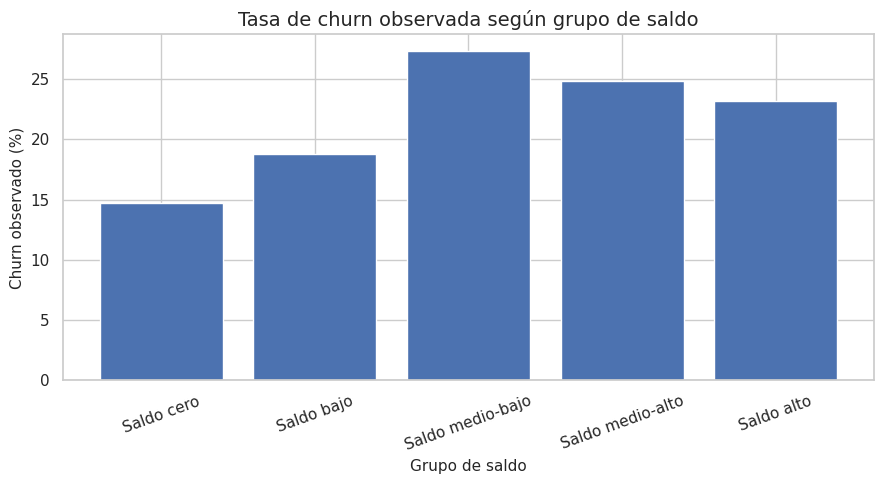

In [ ]:
# ============================================================
# 5. GRÁFICO: CHURN OBSERVADO POR GRUPO DE SALDO
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    analisis_saldo["grupo_saldo"].astype(str),
    analisis_saldo["churn_observado"]
)

plt.title("Tasa de churn observada según grupo de saldo")
plt.xlabel("Grupo de saldo")
plt.ylabel("Churn observado (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Conclusión final

El análisis realizado sobre la base de clientes de ABC Bank permitió identificar patrones relevantes de abandono y construir una herramienta predictiva útil para la gestión comercial. Tras evaluar distintos modelos de clasificación, Gradient Boosting fue el que presentó el mejor desempeño global, alcanzando un ROC-AUC de 0.871 y un PR-AUC de 0.718, por lo que fue seleccionado como modelo final. Además, desde una perspectiva económica, el umbral de decisión más conveniente fue aproximadamente 0.31, lo que permitió priorizar mejor a los clientes con mayor riesgo de fuga.

El análisis de importancia de variables y la segmentación de resultados muestran que el churn está explicado principalmente por la edad, la cantidad de productos contratados, la actividad del cliente, el saldo y el país. En particular, se observó que los clientes de 41 a 60 años presentan un riesgo de abandono considerablemente superior al de los clientes jóvenes, destacando especialmente el grupo de 51 a 60 años, que exhibe la mayor tasa de churn observada. También se identificó que los clientes inactivos tienen una tasa de abandono mucho más alta que los activos, lo que convierte a la actividad transaccional en una señal clave de alerta temprana.

En relación con la vinculación comercial, los resultados indican que los clientes con 2 productos son los más estables, mientras que aquellos con 1 producto presentan una mayor propensión a abandonar. Asimismo, los segmentos con 3 o 4 productos muestran niveles de churn extremadamente altos, aunque deben interpretarse con cautela debido a su menor tamaño muestral. Esto sugiere que tanto la baja vinculación como una vinculación posiblemente excesiva o mal diseñada pueden estar asociadas a mayores niveles de fuga.

Desde el punto de vista financiero, los clientes con saldo positivo presentan mayor riesgo que los clientes con saldo cero, especialmente aquellos ubicados en los grupos de saldo medio-bajo y saldo medio-alto. Esto es relevante porque se trata de clientes con mayor valor potencial para el banco. A nivel geográfico, Alemania destaca como el mercado con peores indicadores de churn, tanto en probabilidad media estimada como en churn observado, por lo que debiera ser un foco prioritario de revisión comercial y de servicio.

En términos de negocio, el modelo permite identificar segmentos prioritarios para acciones de retención. El perfil de mayor riesgo corresponde, en general, a clientes de edad media o madura, inactivos, con saldo positivo, con un solo producto o ciertos perfiles de sobre-vinculación, y con mayor presencia en Alemania. En consecuencia, las campañas de retención del próximo trimestre deberían concentrarse en estos clientes, utilizando estrategias como reactivación comercial, revisión de beneficios, personalización de ofertas, cross-selling inteligente y contacto preventivo.

Finalmente, este análisis demuestra que el modelo predictivo no solo permite anticipar el churn, sino también orientar decisiones concretas de negocio. Su integración en campañas de retención puede ayudar a reducir pérdidas de clientes y a usar de manera más eficiente el presupuesto comercial. Por tanto, se recomienda implementar un esquema de scoring periódico, intervención segmentada según riesgo y valor, y monitoreo continuo de resultados para ajustar la estrategia de retención en el tiempo.